# PetClassNet — Proposed prototype (T-CBF)

**For outline defense: exactly 25 epochs, seed 42, twelve joint species–condition categories, one shared 70/15/15 split.**

Targeted augmentation T (G plus brightness/contrast/centered scale) and class-balanced focal loss CBF. Both prototypes use original ImageNet EfficientNet-B0, global average pooling, dropout 0.2 and a twelve-output softmax. The proposed enhancements change the training method; they do not replace the B0 backbone.

The literature baseline [23] is *Cat Skin Disease Diagnosis Using EfficientNetV2 for Lightweight Processing on Low-Resource Devices*, which includes B0 in its comparison. This notebook is the paper's adapted G-CE control on your twelve-class cat/dog data, not an exact reproduction of the literature study. No published accuracy is treated as directly comparable.

**Run baseline first, then proposed.** In Colab choose **Runtime → Change runtime type → T4 GPU**; the recommended **Runtime Version 2026.07** uses Python 3.12. Run installation first, **always restart the session after installation**, then run Environment check before mounting Drive or running any definitions. Do not run both notebooks simultaneously against the same output folder. The paper's 100-epoch final protocol remains separate.

Dataset: `/content/drive/MyDrive/thesis/data`. It must contain `cat` and `dog`, with one disease folder under each. `Cats`/`Dogs` and names such as `Ringworm in Cat` also work. No images or results are embedded in this notebook.
**12-class scope:** skin, eye, ear and dental conditions. Cat and dog versions of the same condition are separate labels. Do not reuse the older seven-class models or output folder.


## 1. Install, restart, then verify the environment
Recommended Colab runtime: **2026.07**, **T4 GPU** (Python 3.12). The installer fixes NumPy/SciPy versions, verifies fresh imports in a separate process, then asks you to restart. **After installation, stop and choose Runtime → Restart session.** Continue with the next Environment check cell. If you run all cells again after the restart, installation is reused automatically. The check blocks later cells until a restart has occurred.

In [1]:
"""Colab package setup: no scientific-library imports in the installing kernel."""
import importlib.metadata
import json
import os
from pathlib import Path
import subprocess
import sys

SETUP_VERSION = 'petclassnet-prototype25-environment-v2'
SETUP_MARKER = Path('/content/petclassnet_prototype25_environment.json')
EXPECTED_PACKAGES = {
    'tensorflow': '2.20.0', 'keras': '3.12.0', 'numpy': '2.2.6',
    'scipy': '1.15.3', 'pandas': '2.3.3', 'Pillow': '11.3.0',
    'scikit-learn': '1.7.2', 'matplotlib': '3.10.7',
}

if sys.version_info[:2] not in {(3, 11), (3, 12), (3, 13)}:
    raise RuntimeError('Select Runtime > Change runtime type > Runtime Version 2026.07 '
                       '(Python3.12) and T4 GPU, then run this cell again.')

installed_versions = {}
for distribution in EXPECTED_PACKAGES:
    try:
        installed_versions[distribution] = importlib.metadata.version(distribution)
    except importlib.metadata.PackageNotFoundError:
        installed_versions[distribution] = None

saved_setup = {}
if SETUP_MARKER.is_file():
    try:
        saved_setup = json.loads(SETUP_MARKER.read_text(encoding='utf-8'))
    except (OSError, ValueError):
        pass

reusable_setup = (saved_setup.get('setup_version') == SETUP_VERSION
                  and saved_setup.get('expected_packages') == EXPECTED_PACKAGES
                  and saved_setup.get('probe_passed') is True
                  and installed_versions == EXPECTED_PACKAGES)

if not reusable_setup:
    print('Installing the fixed environment. Keep this cell running until the verification finishes.')
    specs = [f'{name}=={version}' for name, version in EXPECTED_PACKAGES.items()]
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade',
                           '--no-cache-dir', '--only-binary=:all:', *specs])
    # Replace both Python files and compiled wheels. Reinstall ONLY NumPy/SciPy,
    # avoiding a full TensorFlow redownload and avoiding unrequested dependency upgrades.
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--no-cache-dir',
                           '--only-binary=:all:', '--force-reinstall', '--no-deps',
                           'numpy==2.2.6', 'scipy==1.15.3'])
    # Test disk-installed packages in a NEW process. The notebook process can still
    # have old binaries in memory, so it must restart even if this probe succeeds.
    probe_code = '''import json, importlib.metadata
import numpy as np
import numpy.strings
from scipy.fft import dctn
import pandas, sklearn, matplotlib, PIL, tensorflow, keras
assert np.strings.upper(np.array(["cat", "dog"])).tolist() == ["CAT", "DOG"]
assert np.isfinite(dctn(np.ones((8, 8)), norm="ortho")).all()
expected = EXPECTED_JSON_PLACEHOLDER
actual = {name: importlib.metadata.version(name) for name in expected}
assert actual == expected, (actual, expected)
print(json.dumps(actual, sort_keys=True))
'''.replace('EXPECTED_JSON_PLACEHOLDER', repr(EXPECTED_PACKAGES))
    probe = subprocess.run([sys.executable, '-c', probe_code], capture_output=True, text=True)
    if probe.returncode != 0:
        print(probe.stdout[-2000:])
        print(probe.stderr[-4000:])
        raise RuntimeError('Fresh-process environment verification failed. Select Colab Runtime Version '
                           '2026.07 with T4 GPU and rerun setup. Do not continue to data/training cells.')
    print('Fresh-process package verification passed:', probe.stdout.strip().splitlines()[-1])
    SETUP_MARKER.parent.mkdir(parents=True, exist_ok=True)
    SETUP_MARKER.write_text(json.dumps({
        'setup_version': SETUP_VERSION, 'expected_packages': EXPECTED_PACKAGES,
        'installer_pid': os.getpid(), 'probe_passed': True,
    }, indent=2), encoding='utf-8')
    saved_setup = json.loads(SETUP_MARKER.read_text(encoding='utf-8'))

if saved_setup.get('installer_pid') == os.getpid():
    print('\nSTOP HERE: choose Runtime > Restart session NOW.')
    print('After reconnecting, run the next Environment check cell, then mount Drive and continue.')
    print('If you choose Run all after restarting, this setup cell will reuse the verified installation.')
else:
    print('Fixed packages are already installed and the notebook process has restarted. Continue to Environment check.')

Fixed packages are already installed and the notebook process has restarted. Continue to Environment check.


In [2]:
"""Stop before scientific imports if NumPy/SciPy were replaced in this kernel."""
import importlib.metadata
import json
import os
from pathlib import Path
import sys


def validate_environment_setup(marker, installed, current_pid):
    expected = {
        'tensorflow': '2.20.0', 'keras': '3.12.0', 'numpy': '2.2.6',
        'scipy': '1.15.3', 'pandas': '2.3.3', 'Pillow': '11.3.0',
        'scikit-learn': '1.7.2', 'matplotlib': '3.10.7',
    }
    if (marker.get('setup_version') != 'petclassnet-prototype25-environment-v2'
            or marker.get('expected_packages') != expected or not marker.get('probe_passed')):
        raise RuntimeError('Run the installation cell first, then choose Runtime > Restart session.')
    if marker.get('installer_pid') == current_pid:
        raise RuntimeError('RESTART REQUIRED: choose Runtime > Restart session, reconnect, '
                           'then run this Environment check cell again. Old NumPy binaries may still be in memory.')
    if installed != expected:
        raise RuntimeError('Package versions differ from this prototype. Rerun installation, restart the session, '
                           'and run this Environment check again. Do not install other packages during this comparison.')
    return True


setup_marker = Path('/content/petclassnet_prototype25_environment.json')
if not setup_marker.is_file():
    raise RuntimeError('Run the installation cell first. After it finishes, restart the session.')
setup_record = json.loads(setup_marker.read_text(encoding='utf-8'))
disk_versions = {}
for name in setup_record.get('expected_packages', {}):
    try:
        disk_versions[name] = importlib.metadata.version(name)
    except importlib.metadata.PackageNotFoundError:
        disk_versions[name] = None
validate_environment_setup(setup_record, disk_versions, os.getpid())

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
try:
    import numpy as np
    import numpy.strings
    import scipy
    from scipy.fft import dctn
    import pandas as pd
    import PIL
    import sklearn
    import matplotlib
    import tensorflow as tf
    import keras
    from IPython.display import display
    loaded_versions = {
        'tensorflow': tf.__version__, 'keras': keras.__version__, 'numpy': np.__version__,
        'scipy': scipy.__version__, 'pandas': pd.__version__, 'Pillow': PIL.__version__,
        'scikit-learn': sklearn.__version__, 'matplotlib': matplotlib.__version__,
    }
    if loaded_versions != disk_versions:
        raise RuntimeError('Loaded package versions differ from the installed files. Restart the session.')
    assert np.strings.upper(np.array(['cat', 'dog'])).tolist() == ['CAT', 'DOG']
    assert np.isfinite(dctn(np.ones((8, 8)), norm='ortho')).all()
except Exception as error:
    raise RuntimeError('Environment check failed before training. Restart the session; if it still fails, '
                       'select Colab Runtime Version 2026.07 and rerun installation. Original error: '
                       f'{type(error).__name__}: {error}') from error

for gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass
print('Python:', sys.version.split()[0])
print('Verified package versions:', json.dumps(loaded_versions, indent=2))
print('NumPy:', np.__file__)
print('SciPy:', scipy.__file__)
print('GPU:', tf.config.list_physical_devices('GPU') or 'None; select Runtime > Change runtime type > T4 GPU.')
print('Environment ready. Continue with the Drive-mount cell.')

Python: 3.13.15
Verified package versions: {
  "tensorflow": "2.20.0",
  "keras": "3.12.0",
  "numpy": "2.2.6",
  "scipy": "1.15.3",
  "pandas": "2.3.3",
  "Pillow": "11.3.0",
  "scikit-learn": "1.7.2",
  "matplotlib": "3.10.7"
}
NumPy: /usr/local/lib/python3.13/dist-packages/numpy/__init__.py
SciPy: /usr/local/lib/python3.13/dist-packages/scipy/__init__.py
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Environment ready. Continue with the Drive-mount cell.


## 2. Mount Drive and check the dataset path
Authorize the Drive mount in your own Colab account. Outputs go beside `data`, inside `thesis/PetClassNet_12_Class_Prototype_25`.

In [3]:
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

DATA_ROOT = Path('/content/drive/MyDrive/Thesis/data')
# BOTH notebooks must keep the SAME OUTPUT_ROOT. Run them one after the other.
OUTPUT_ROOT = Path('/content/drive/MyDrive/thesis/PetClassNet_12_Class_Prototype_25')
LOCAL_CACHE = Path('/content/PetClassNet_12_Class_Prototype_25_cache')
CONFIGURATION = 'T-CBF'  # This notebook trains ONLY this model.
SEED = 42
TOTAL_EPOCHS = 25
WARMUP_EPOCHS = 5
FINE_TUNE_EPOCHS = 20
BATCH_SIZE = 32

# Optional CSVs based on documented case IDs/review decisions; leave None if unavailable.
# Case CSV: relative_path,group_id. Review CSV: relative_path,action,reason[,class_name].
GROUP_IDS_CSV = None
DATA_REVIEW_CSV = None
RUN_TRAINING = True
# Reserve the test partition by default for this outline-defense demonstration.
# Set True ONLY after both notebooks finish all25 epochs with locked checkpoints.
RUN_TEST_COMPARISON = False

if not DATA_ROOT.is_dir():
    raise FileNotFoundError(f'Cannot find {DATA_ROOT}. Check capitalization and the folder in My Drive.')
print('Disease subfolders found:')
for species in sorted(p for p in DATA_ROOT.iterdir() if p.is_dir()):
    print(species.name, '->', [p.name for p in species.iterdir() if p.is_dir()])

Mounted at /content/drive
Disease subfolders found:
Cats -> ['Flea Allergy in Cat', 'Ear Mites in Cat', 'Ringworm in Cat', 'Scabies in Cat', 'Dental Disease in Cat', 'Eye Infection in Cat']
Dogs -> ['Flea Allergy in Dog', 'Fungal Infection in Dog', 'Dental Disease in Dog', 'Eye Infection in Dog', 'Hot Spots in Dog', 'Mange in Dog']


## 3. Define the shared methods
These four cells contain the complete helpers. Run them unchanged; no helper uploads are required. Both notebooks include identical data, architecture, metric and export code.

In [4]:
"""PetClassNet data audit, reversible cleaning, and one protected split manifest.

This cell is self-contained. It never edits the uploaded archive or source images.
Identifiable image-family IDs are technical observations, not animal/case IDs.
"""
from pathlib import Path, PurePosixPath
from collections import defaultdict, Counter
import hashlib
import json
import os
import re
import shutil
import stat
import tempfile
import zipfile

import numpy as np
import pandas as pd
from PIL import Image, ImageOps
from scipy.fft import dctn

CLASS_NAMES = ['Cat - Dental Disease', 'Cat - Ear Mites', 'Cat - Eye Infection', 'Cat - Ringworm', 'Cat - Scabies', 'Cat - Flea Allergy', 'Dog - Dental Disease', 'Dog - Eye Infection', 'Dog - Fungal Infection', 'Dog - Hot Spots', 'Dog - Mange', 'Dog - Flea Allergy']
NUM_CLASSES = len(CLASS_NAMES)
EXCLUDED_FOLDERS = set()
FOLDER_MAP = {
    name: f"{name.split(' - ')[0]}s/{name.split(' - ')[1]} in {name.split(' - ')[0]}"
    for name in CLASS_NAMES
}
THESIS_COUNTS = dict(zip(CLASS_NAMES, [316, 131, 137, 303, 260, 271, 129, 215, 133, 139, 604, 117]))
DATA_POLICY_VERSION = "petclassnet-12class-prototype25-data-70-15-15-v2"
SPLIT_SEED = 42
SPLIT_FRACTIONS = {"train": 0.70, "validation": 0.15, "test": 0.15}
NEAR_PHASH_DISTANCE = 4
NEAR_MIN_CORRELATION = 0.985
NEAR_MAX_RGB_RMSE = 0.06
NEAR_MAX_LOG_ASPECT_DIFFERENCE = 0.15


def _sha256_bytes(value):
    return hashlib.sha256(value).hexdigest()


def _hash_file(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


def _json_bytes(value):
    return json.dumps(value, sort_keys=True, separators=(",", ":"), ensure_ascii=False).encode("utf-8")


def _atomic_json(path, value):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile(mode="w", encoding="utf-8", dir=path.parent, delete=False, suffix=".json") as handle:
        json.dump(value, handle, indent=2, ensure_ascii=False, allow_nan=False)
        temporary = Path(handle.name)
    os.replace(temporary, path)


def _atomic_csv(path, frame):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile(mode="w", encoding="utf-8", newline="", dir=path.parent, delete=False, suffix=".csv") as handle:
        frame.to_csv(handle, index=False)
        temporary = Path(handle.name)
    os.replace(temporary, path)


def decode_source_rgb(path):
    """Content-aware reader; fully decode all frames, use the first RGB frame.

    WEBP/GIF and misleading suffixes work here. Pixels remain in [0,255].
    EfficientNet normalization belongs inside the model, not this reader.
    """
    with Image.open(path) as im:
        for frame in range(getattr(im, "n_frames", 1)):
            im.seek(frame)
            im.load()
        im.seek(0)
        return ImageOps.exif_transpose(im).convert("RGB").copy()










def _folder_key(value):
    return re.sub(r'[^a-z0-9]', '', str(value).casefold())


def locate_dataset_root(search_root):
    """Resolve singular/plural species names and explicit condition aliases.

    A disease subfolder is required; cat/dog alone cannot provide disease labels.
    Unknown subfolders are reported and excluded, never assigned new class IDs.
    """
    global FOLDER_MAP, EXCLUDED_FOLDERS, SPECIES_FOLDERS
    root = Path(search_root).expanduser().resolve(strict=True)
    if not root.is_dir():
        raise ValueError('DATA_ROOT must be the data folder containing cat and dog.')
    children = [p for p in root.iterdir() if p.is_dir()]
    species_dirs = {}
    for species in ['Cat', 'Dog']:
        matches = [p for p in children if _folder_key(p.name) in {species.lower(), species.lower() + 's'}]
        if len(matches) != 1:
            raise ValueError(f'Expected one {species.lower()} or {species.lower()}s folder under {root}; found {len(matches)}.')
        species_dirs[species] = matches[0]
    mapping, excluded = {}, set()
    for species, parent in species_dirs.items():
        folders = [p for p in parent.iterdir() if p.is_dir()]
        for class_name in [n for n in CLASS_NAMES if n.startswith(species + ' - ')]:
            condition = class_name.split(' - ')[1]
            aliases = {_folder_key(s) for s in [condition, f'{condition} in {species}',
                      f'{species} {condition}', f'{species}s {condition}']}
            matches = [p for p in folders if _folder_key(p.name) in aliases]
            if len(matches) != 1:
                available = ', '.join(sorted(p.name for p in folders)) or '(no disease subfolders)'
                raise ValueError(f'Missing or ambiguous folder for {class_name}. Found: {available}. '
                                 f'Use a folder named "{condition}" or "{condition} in {species}".')
            mapping[class_name] = matches[0].relative_to(root).as_posix()
        accepted = set(mapping.values())
        excluded.update(p.relative_to(root).as_posix() for p in folders
                        if p.relative_to(root).as_posix() not in accepted)
        loose_files = [p for p in parent.iterdir() if p.is_file() and not p.name.startswith('.')]
        if loose_files:
            raise ValueError(f'{parent} has loose files. Put photographs inside their disease subfolders; '
                             'species-only labels cannot train a twelve-disease classifier.')
    FOLDER_MAP = mapping
    EXCLUDED_FOLDERS = excluded
    SPECIES_FOLDERS = [p.name for p in species_dirs.values()]
    print('Recognized disease folders:', json.dumps(FOLDER_MAP, indent=2))
    if excluded:
        print('Excluded folders outside the twelve supported categories:', sorted(excluded))
    return root



class _DisjointSet:
    def __init__(self, values):
        self.parent = {value: value for value in values}

    def find(self, value):
        if self.parent[value] != value:
            self.parent[value] = self.find(self.parent[value])
        return self.parent[value]

    def union(self, values):
        roots = sorted({self.find(value) for value in values})
        for root in roots[1:]:
            self.parent[root] = roots[0]

    def components(self):
        result = defaultdict(list)
        for value in self.parent:
            result[self.find(value)].append(value)
        return [sorted(values) for values in sorted(result.values(), key=lambda values: min(values))]


def _technical_id(prefix, paths):
    return prefix + "_" + _sha256_bytes("\n".join(sorted(paths)).encode("utf-8"))[:24]


def _source_stem(filename):
    stem = Path(filename).stem
    has_rf = bool(re.search(r"\.rf\.[^.]+$", stem, flags=re.I))
    stem = re.sub(r"\.rf\.[^.]+$", "", stem, flags=re.I)
    stem = re.sub(r"_(jpg|jpeg|png|webp|gif|bmp|tiff?)$", "", stem, flags=re.I)
    return stem.casefold(), has_rf


def _oriented_thumbnail_data(rgb):
    """64-bit canonical pHash and 8 oriented 32px RGB thumbnails.

    Min-hash canonicalization is exactly invariant to the 8 dihedral transforms.
    It is a candidate screen, not a complete proof of near-duplicate identity.
    """
    tiny = rgb.resize((32, 32), Image.Resampling.LANCZOS)
    transforms = [None, Image.Transpose.ROTATE_90, Image.Transpose.ROTATE_180,
                  Image.Transpose.ROTATE_270, Image.Transpose.FLIP_LEFT_RIGHT,
                  Image.Transpose.FLIP_TOP_BOTTOM, Image.Transpose.TRANSPOSE,
                  Image.Transpose.TRANSVERSE]
    hashes, thumbs = [], []
    for transform in transforms:
        view = tiny if transform is None else tiny.transpose(transform)
        thumbnail = np.asarray(view, dtype=np.float32) / 255.0
        gray = np.asarray(view.convert("L"), dtype=np.float32)
        frequencies = dctn(gray, type=2, norm="ortho")[:8, :8].reshape(-1)[1:]
        bits = frequencies > np.median(frequencies)
        value = 0
        for bit in bits:
            value = (value << 1) | int(bit)
        hashes.append(value)
        thumbs.append(thumbnail)
    return min(hashes), np.stack(thumbs), float(np.std(np.asarray(tiny.convert("L"))))


def _inventory_dataset(root, screen_near_duplicates):
    records, thumbnails = [], {}
    expected_folders = set(FOLDER_MAP.values())
    detected_folders = set()
    for species in SPECIES_FOLDERS:
        detected_folders.update(path.relative_to(root).as_posix() for path in (root / species).iterdir() if path.is_dir())
    if not expected_folders.issubset(detected_folders) or detected_folders - expected_folders - EXCLUDED_FOLDERS:
        raise ValueError(f"Class-folder mismatch. Missing: {sorted(expected_folders-detected_folders)}; extra: {sorted(detected_folders-expected_folders-EXCLUDED_FOLDERS)}")
    source_files = []
    for label, class_name in enumerate(CLASS_NAMES):
        folder = root / FOLDER_MAP[class_name]
        for path in sorted(folder.rglob("*")):
            if path.is_symlink():
                raise ValueError(f"Source image path is a symbolic link: {path}")
            if path.is_file():
                source_files.append((path, label, class_name))
    for index, (path, label, class_name) in enumerate(source_files):
        relative = path.relative_to(root).as_posix()
        stem, rf = _source_stem(path.name)
        record = {
            "relative_path": relative, "label": label, "class_name": class_name,
            "folder": FOLDER_MAP[class_name], "basename": path.name,
            "extension": path.suffix.lower(), "file_bytes": path.stat().st_size,
            "byte_sha256": _hash_file(path), "rgb_sha256": "", "format": "",
            "width": 0, "height": 0, "frames": 0, "readable": False, "error": "",
            "roboflow_name": rf, "source_family": FOLDER_MAP[class_name] + "::" + stem,
            "phash63": "", "gray_std": 0.0,
        }
        try:
            with Image.open(path) as image:
                record["format"] = image.format or ""
                record["frames"] = getattr(image, "n_frames", 1)
            rgb = decode_source_rgb(path)
            record.update(width=rgb.width, height=rgb.height, readable=True)
            record["rgb_sha256"] = _sha256_bytes(f"RGB:{rgb.width}:{rgb.height}:".encode("ascii") + rgb.tobytes())
            if screen_near_duplicates:
                phash, thumbs, gray_std = _oriented_thumbnail_data(rgb)
                record["phash63"] = f"{phash:016x}"
                record["gray_std"] = gray_std
                thumbnails[relative] = thumbs
        except Exception as error:
            record["error"] = f"{type(error).__name__}: {error}"
        records.append(record)
        if (index + 1) % 500 == 0:
            print(f"Audited {index+1:,}/{len(source_files):,} files")
    if not records:
        raise ValueError("No files were found in the twelve recognized disease class folders.")
    return pd.DataFrame(records), thumbnails


def _read_user_mapping(csv_path, inventory, kind):
    if csv_path is None:
        return [], None
    csv_path = Path(csv_path).expanduser().resolve(strict=True)
    frame = pd.read_csv(csv_path, dtype=str, keep_default_na=False)
    required = {"relative_path", "group_id"} if kind == "case" else {"relative_path", "action", "reason"}
    if not required.issubset(frame.columns):
        raise ValueError(f"{kind} CSV requires columns: {sorted(required)}")
    valid_paths = set(inventory["relative_path"])
    rows, seen = [], {}
    for row in frame.to_dict("records"):
        relative = row["relative_path"].strip().replace("\\", "/")
        if relative not in valid_paths:
            raise ValueError(f"{kind} CSV references an unknown path: {relative}. Use paths relative to data/, e.g. Cats/...")
        cleaned = {"relative_path": relative}
        if kind == "case":
            group_id = row["group_id"].strip()
            if not group_id:
                raise ValueError(f"Blank supplied case/group ID for {relative}")
            cleaned["group_id"] = group_id
        else:
            action, reason = row["action"].strip().lower(), row["reason"].strip()
            if action not in {"exclude", "retain", "relabel"} or not reason:
                raise ValueError("Review actions must be exclude, retain, or relabel, with a nonblank reason.")
            cleaned.update(action=action, reason=reason, class_name=row.get("class_name", "").strip())
            if action == "relabel" and cleaned["class_name"] not in CLASS_NAMES:
                raise ValueError(f"Review relabel needs an exact thesis class_name for {relative}")
        if relative in seen and seen[relative] != cleaned:
            raise ValueError(f"Conflicting {kind} CSV entries for {relative}")
        seen[relative] = cleaned
    rows = sorted(seen.values(), key=lambda row: row["relative_path"])
    return rows, _sha256_bytes(_json_bytes(rows))


def _duplicate_groups(frame, column):
    grouped = defaultdict(list)
    for row in frame.to_dict("records"):
        if row[column]:
            grouped[row[column]].append(row["relative_path"])
    return [sorted(paths) for _, paths in sorted(grouped.items()) if len(paths) > 1]


def _screen_near_pairs(inventory, thumbnails):
    usable = inventory.loc[inventory["readable"] & (inventory["gray_std"] >= 5.0)].sort_values("relative_path")
    rows = usable.to_dict("records")
    candidates, hash_hits = [], 0
    for i, left in enumerate(rows):
        left_hash = int(left["phash63"], 16)
        left_view = thumbnails[left["relative_path"]][0]
        left_flat = left_view.reshape(-1)
        for right in rows[i+1:]:
            distance = (left_hash ^ int(right["phash63"], 16)).bit_count()
            if distance > NEAR_PHASH_DISTANCE:
                continue
            hash_hits += 1
            left_aspect = left["width"] / left["height"]
            right_aspect = right["width"] / right["height"]
            aspect_gap = min(abs(np.log(left_aspect / right_aspect)), abs(np.log(left_aspect * right_aspect)))
            if aspect_gap > NEAR_MAX_LOG_ASPECT_DIFFERENCE:
                continue
            best = None
            for view in thumbnails[right["relative_path"]]:
                flat = view.reshape(-1)
                rmse = float(np.sqrt(np.mean((flat-left_flat)**2)))
                if rmse > NEAR_MAX_RGB_RMSE:
                    continue
                correlation = float(np.corrcoef(left_flat, flat)[0, 1])
                if not np.isfinite(correlation) or correlation < NEAR_MIN_CORRELATION:
                    continue
                score = (rmse, -correlation)
                if best is None or score < best[0]:
                    best = (score, correlation, rmse)
            if best is not None:
                candidates.append({"left_path": left["relative_path"], "right_path": right["relative_path"],
                    "phash_distance": distance, "correlation": best[1], "rgb_rmse": best[2],
                    "cross_label": left["label"] != right["label"],
                    "exact_rgb": left["rgb_sha256"] == right["rgb_sha256"],
                    "decision": "hold_in_same_split_group_only; no automatic exclusion"})
    return pd.DataFrame(candidates, columns=["left_path", "right_path", "phash_distance", "correlation", "rgb_rmse", "cross_label", "exact_rgb", "decision"]), hash_hits


def _select_split(eligible):
    """Seeded whole-group allocation balanced by class and total image counts.

    Uses only labels/counts/group evidence, never model scores or images from a
    held-out partition. Known relationships and nonzero class support are hard
    constraints; deviations from requested ratios are explicitly reported.
    """
    eligible = eligible.sort_values('relative_path').reset_index(drop=True)
    k = len(CLASS_NAMES)
    if set(eligible.label.astype(int)) != set(range(k)):
        raise ValueError('Cleaning left a disease class without examples.')
    group_ids = sorted(eligible.group_id.unique())
    group_counts = pd.crosstab(eligible.group_id, eligible.label).reindex(
        index=group_ids, columns=range(k), fill_value=0).to_numpy(dtype=int)
    support = (group_counts > 0).sum(axis=0)
    if np.any(support < 3):
        deficient = {CLASS_NAMES[i]: int(v) for i, v in enumerate(support) if v < 3}
        raise ValueError(f'Each disease class needs at least three observed groups for three disjoint supported partitions: {deficient}. Resolve provenance/data support rather than split a group.')
    fractions = np.array(list(SPLIT_FRACTIONS.values()), dtype=float)
    class_total = group_counts.sum(axis=0)
    targets = fractions[:, None] * class_total
    totals = fractions * class_total.sum()
    denominator = np.maximum(targets, 1)
    def objective(counts):
        return float(np.sum((counts-targets)**2/denominator) +
                     np.sum((counts.sum(axis=1)-totals)**2/np.maximum(totals, 1)))
    rng = np.random.default_rng(SPLIT_SEED)
    sizes = group_counts.sum(axis=1)
    priority = np.max(group_counts / class_total, axis=1)
    candidates = []
    for trial in range(64):
        order = np.argsort(-(priority * rng.uniform(.8, 1.2, len(group_ids))), kind='stable')
        assigned = np.full(len(group_ids), -1, dtype=int)
        counts = np.zeros((3, k), dtype=int)
        remaining_support = support.copy()
        for g in order:
            vector = group_counts[g]
            remaining_support -= vector > 0
            options = []
            for destination in rng.permutation(3):
                proposed = counts.copy(); proposed[destination] += vector
                # Reserve enough remaining groups to cover every class in every split.
                if np.any((proposed == 0).sum(axis=0) > remaining_support):
                    continue
                options.append((objective(proposed), int(destination)))
            if not options:
                break
            destination = min(options, key=lambda pair: pair[0])[1]
            counts[destination] += vector; assigned[g] = destination
        if np.all(assigned >= 0) and np.all(counts > 0):
            candidates.append((objective(counts), trial, assigned.copy(), counts.copy()))
    if not candidates:
        raise ValueError('No supported disjoint group allocation was found. Review group provenance and class support; group separation will not be weakened.')
    refined = []
    for _, trial, assigned, counts in sorted(candidates, key=lambda x: (x[0], x[1]))[:8]:
        score = objective(counts)
        for iteration in range(10):
            moved = False
            for g in rng.permutation(len(group_ids)):
                origin = assigned[g]; vector = group_counts[g]
                if np.any(counts[origin] - vector <= 0):
                    continue
                for destination in range(3):
                    if destination == origin:
                        continue
                    proposed = counts.copy(); proposed[origin] -= vector; proposed[destination] += vector
                    proposed_score = objective(proposed)
                    if proposed_score < score - 1e-10:
                        assigned[g] = destination; counts = proposed; score = proposed_score
                        moved = True; break
            if not moved:
                break
        refined.append((score, trial, assigned, counts))
    score, trial, assigned, counts = min(refined, key=lambda x: (x[0], x[1]))
    mapping = {g: list(SPLIT_FRACTIONS)[int(a)] for g, a in zip(group_ids, assigned)}
    manifest = eligible.copy(); manifest['split'] = manifest.group_id.map(mapping)
    achieved = {name: int(counts[i].sum()) for i, name in enumerate(SPLIT_FRACTIONS)}
    return manifest, {'method': '64 seeded greedy whole-group allocations; best 8 refined by class-support-preserving single-group moves',
                      'split_seed': SPLIT_SEED, 'requested_fractions': SPLIT_FRACTIONS,
                      'selection_score': score, 'selected_trial': trial,
                      'achieved_counts': achieved,
                      'achieved_fractions': {name: count/len(manifest) for name, count in achieved.items()},
                      'class_support_counts': counts.tolist(), 'counting_unit': 'retained image rows; whole observed groups kept together'}


def _validate_saved_manifest(manifest, eligible):
    required = {"relative_path", "label", "class_name", "group_id", "split", "byte_sha256", "rgb_sha256", "source_family"}
    if not required.issubset(manifest.columns) or manifest["relative_path"].duplicated().any():
        raise ValueError("Saved split manifest has missing columns or duplicate paths.")
    if set(manifest["relative_path"]) != set(eligible["relative_path"]):
        raise ValueError("Saved manifest membership does not match current eligible data.")
    for column in required-{"split", "relative_path"}:
        current = eligible.set_index("relative_path")[column].astype(str).sort_index()
        saved = manifest.set_index("relative_path")[column].astype(str).sort_index()
        if not current.equals(saved):
            raise ValueError(f"Saved manifest differs from current data in {column}.")
    if set(manifest["split"]) != set(SPLIT_FRACTIONS):
        raise ValueError("Saved manifest must contain train, validation, and test.")
    if (manifest.groupby("group_id")["split"].nunique() > 1).any():
        raise ValueError("Observed source/case groups cross saved split partitions.")
    if (manifest.groupby("rgb_sha256")["split"].nunique() > 1).any():
        raise ValueError("Exact decoded duplicates cross saved partitions.")
    for split in SPLIT_FRACTIONS:
        if set(manifest.loc[manifest["split"] == split, "label"].astype(int)) != set(range(NUM_CLASSES)):
            raise ValueError(f"Saved {split} partition does not contain all twelve classes.")


def prepare_data(dataset_root, output_root, group_csv=None, representative_per_family=True,
                 review_csv=None, screen_near_duplicates=True):
    """Audit real images, apply logged conservative policy, reuse one protected split.

    group_csv: relative_path,group_id supplied from known cases. This merges split
    groups only; it never collapses distinct photographs into one representative.
    review_csv: relative_path,action,reason[,class_name]. Explicit relabels require
    a supplied exact class name. retain prefers a representative when eligible;
    it cannot override undecodable input, multi-frame policy, or exact conflicts.
    """
    root = locate_dataset_root(dataset_root)
    output_root = Path(output_root).expanduser().resolve()
    if output_root == root or output_root.is_relative_to(root):
        raise ValueError("Experiment outputs must be outside the source dataset tree.")
    manifests_dir = output_root / "manifests"
    manifests_dir.mkdir(parents=True, exist_ok=True)
    manifest_path, metadata_path = manifests_dir / "split_manifest.csv", manifests_dir / "split_metadata.json"
    if manifest_path.exists() != metadata_path.exists():
        raise ValueError("Incomplete saved manifest/metadata pair. Use a new experiment folder or recover both files.")
    print(f"Actual dataset root: {root}")
    scope_rows = []
    for folder in sorted(EXCLUDED_FOLDERS):
        if (root / folder).is_dir():
            for path in sorted((root / folder).rglob('*')):
                if path.is_file():
                    scope_rows.append({'relative_path': path.relative_to(root).as_posix(),
                                       'folder': folder, 'reason': 'outside the twelve-class disease scope'})
    _atomic_csv(manifests_dir / 'scope_exclusions.csv', pd.DataFrame(scope_rows, columns=['relative_path', 'folder', 'reason']))
    inventory, thumbnails = _inventory_dataset(root, screen_near_duplicates)
    raw_inventory = inventory.copy()
    case_rows, case_digest = _read_user_mapping(group_csv, inventory, "case")
    review_rows, review_digest = _read_user_mapping(review_csv, inventory, "review")
    review_by_path = {row["relative_path"]: row for row in review_rows}
    inventory["original_label"] = inventory["label"]
    inventory["original_class_name"] = inventory["class_name"]
    for row in review_rows:
        if row["action"] == "relabel":
            mask = inventory["relative_path"] == row["relative_path"]
            inventory.loc[mask, "class_name"] = row["class_name"]
            inventory.loc[mask, "label"] = CLASS_NAMES.index(row["class_name"])
    readable = inventory.loc[inventory["readable"]].copy()
    rows_by_path = {row["relative_path"]: row for row in inventory.to_dict("records")}
    all_paths = inventory["relative_path"].tolist()
    image_families = _DisjointSet(all_paths)
    byte_groups = _duplicate_groups(readable, "byte_sha256")
    rgb_groups = _duplicate_groups(readable, "rgb_sha256")
    for group in byte_groups + rgb_groups:
        image_families.union(group)
    source_groups = []
    for _, frame in readable.groupby("source_family", sort=True):
        if len(frame) > 1 and frame["roboflow_name"].any():
            paths = sorted(frame["relative_path"])
            source_groups.append(paths)
            image_families.union(paths)
    image_ids = {}
    for family in image_families.components():
        family_id = _technical_id("image_family", family)
        image_ids.update({path: family_id for path in family})
    inventory["image_family_id"] = inventory["relative_path"].map(image_ids)
    decisions = pd.DataFrame({"relative_path": inventory["relative_path"], "original_label": inventory["original_label"],
        "label": inventory["label"], "class_name": inventory["class_name"], "image_family_id": inventory["image_family_id"],
        "action": "retain", "reason": "readable; no cleaning exclusion", "review_action": "", "review_reason": ""})
    decision_index = {path: index for index, path in enumerate(decisions["relative_path"])}

    def exclude(paths, action, reason):
        for path in paths:
            decisions.loc[decision_index[path], ["action", "reason"]] = [action, reason]

    exclude(inventory.loc[~inventory["readable"], "relative_path"], "exclude_unreadable", "image could not be fully decoded")
    exclude(inventory.loc[inventory["readable"] & (inventory["frames"] > 1), "relative_path"],
            "exclude_multiframe", "multi-frame input excluded; this study specifies one static photograph")
    for row in review_rows:
        index = decision_index[row["relative_path"]]
        decisions.loc[index, ["review_action", "review_reason"]] = [row["action"], row["reason"]]
        if row["action"] == "exclude":
            exclude([row["relative_path"]], "exclude_review", row["reason"])
    active_paths = set(decisions.loc[decisions["action"] == "retain", "relative_path"])
    conflict_groups = []
    for group in rgb_groups:
        active = [path for path in group if path in active_paths]
        if len({rows_by_path[path]["label"] for path in active}) > 1:
            conflict_groups.append(active)
            exclude(active, "quarantine_exact_label_conflict", "identical EXIF-oriented RGB pixels occur under conflicting class labels; human label resolution required")
    active_paths = set(decisions.loc[decisions["action"] == "retain", "relative_path"])
    for group in rgb_groups:
        active = sorted((path for path in group if path in active_paths),
                        key=lambda path: (review_by_path.get(path, {}).get("action") != "retain", path))
        if len(active) > 1:
            exclude(active[1:], "exclude_same_class_exact_duplicate", f"same-class exact RGB duplicate; retained representative {active[0]}")
    exact_policy_retained = int((decisions["action"] == "retain").sum())
    if representative_per_family:
        for family in image_families.components():
            active = [path for path in family if decisions.loc[decision_index[path], "action"] == "retain"]
            if len(active) > 1:
                if len({rows_by_path[path]["label"] for path in active}) > 1:
                    raise ValueError("A retained exact/name image family has mixed labels. Resolve label review before selecting representatives.")
                preferred = sorted(active, key=lambda path: (review_by_path.get(path, {}).get("action") != "retain", rows_by_path[path]["roboflow_name"], path))[0]
                exclude([path for path in active if path != preferred], "exclude_additional_source_family_member",
                        f"one source-family representative policy; retained {preferred}; original/animal identity not verified")
    for row in review_rows:
        if row["action"] == "retain" and decisions.loc[decision_index[row["relative_path"]], "action"] == "quarantine_exact_label_conflict":
            raise ValueError(f"Review retain cannot override unresolved exact-label conflict for {row['relative_path']}; supply justified relabel/exclude decisions.")

    split_families = _DisjointSet(all_paths)
    for family in image_families.components():
        split_families.union(family)
    case_mapping = defaultdict(list)
    for row in case_rows:
        case_mapping[row["group_id"]].append(row["relative_path"])
    supplied_case_by_path = {row["relative_path"]: row["group_id"] for row in case_rows}
    for exact_group in rgb_groups:
        supplied_ids = {supplied_case_by_path[path] for path in exact_group if path in supplied_case_by_path}
        if len(supplied_ids) > 1:
            raise ValueError("Conflicting supplied case IDs describe identical decoded images. Resolve the case mapping before creating a split.")
    for supplied_case_paths in case_mapping.values():
        split_families.union(supplied_case_paths)
    if screen_near_duplicates:
        near_pairs, hash_hits = _screen_near_pairs(inventory, thumbnails)
        for row in near_pairs.to_dict("records"):
            split_families.union([row["left_path"], row["right_path"]])
    else:
        near_pairs = pd.DataFrame(columns=["left_path", "right_path", "phash_distance", "correlation", "rgb_rmse", "cross_label", "exact_rgb", "decision"])
        hash_hits = 0
    split_ids, split_components = {}, []
    for component in split_families.components():
        group_id = _technical_id("split_group", component)
        split_ids.update({path: group_id for path in component})
        split_components.append({"group_id": group_id, "paths": component})
    inventory["group_id"] = inventory["relative_path"].map(split_ids)
    decisions["group_id"] = decisions["relative_path"].map(split_ids)
    retained_paths = set(decisions.loc[decisions["action"] == "retain", "relative_path"])
    manifest_columns = ["relative_path", "label", "class_name", "group_id", "byte_sha256", "rgb_sha256", "source_family"]
    eligible = inventory.loc[inventory["relative_path"].isin(retained_paths), manifest_columns].sort_values("relative_path").reset_index(drop=True)
    policy = {
        "version": DATA_POLICY_VERSION, "class_names": CLASS_NAMES, "folder_map": FOLDER_MAP,
        "representative_per_family": bool(representative_per_family), "quarantine_exact_conflicts": True,
        "source_family_rule": "folder-scoped normalized source name; join repeated families with at least one Roboflow marker",
        "case_mapping_digest": case_digest, "review_mapping_digest": review_digest,
        "near_screen": bool(screen_near_duplicates), "near_phash_distance": NEAR_PHASH_DISTANCE,
        "near_min_correlation": NEAR_MIN_CORRELATION, "near_max_rgb_rmse": NEAR_MAX_RGB_RMSE,
        "near_max_log_aspect_difference": NEAR_MAX_LOG_ASPECT_DIFFERENCE,
        "split_seed": SPLIT_SEED, "fractions": SPLIT_FRACTIONS, "split_algorithm": "64 seeded whole-group allocations; best 8 refined; class and total squared target error",
        "decode_rule": "Pillow fully decoded EXIF-oriented RGB [0,255]; raw sizes preserved for hashes; multi-frame inputs excluded",
    }
    data_digest_rows = inventory[["relative_path", "byte_sha256", "rgb_sha256", "label", "readable", "group_id"]].sort_values("relative_path").to_dict("records")
    data_fingerprint = _sha256_bytes(_json_bytes({"policy": policy, "files": data_digest_rows}))
    if metadata_path.exists():
        metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        if metadata.get("data_fingerprint") != data_fingerprint:
            raise ValueError("Dataset, cleaning/review policy, supplied group IDs, or split rules changed. Existing manifest is protected. Use a new OUTPUT_ROOT and rerun all comparisons; do not reuse prior results.")
        if metadata.get("manifest_sha256") != _hash_file(manifest_path):
            raise ValueError("Saved manifest file was changed. Recover the original manifest or use a new OUTPUT_ROOT; do not silently reuse edited partitions.")
        manifest = pd.read_csv(manifest_path, dtype={"relative_path": str, "group_id": str, "byte_sha256": str, "rgb_sha256": str, "source_family": str})
        _validate_saved_manifest(manifest, eligible)
        manifest_sha256 = _hash_file(manifest_path)
        fingerprint = _sha256_bytes(_json_bytes({"data_fingerprint": data_fingerprint, "manifest_sha256": manifest_sha256}))
        if metadata.get("fingerprint") != fingerprint:
            raise ValueError("Saved manifest fingerprint is inconsistent with its data and partition hash. Recover the original metadata or use a new OUTPUT_ROOT.")
        split_info = metadata["split_info"]
        reused_manifest = True
    else:
        manifest, split_info = _select_split(eligible)
        _validate_saved_manifest(manifest, eligible)
        _atomic_csv(manifest_path, manifest)
        manifest_sha256 = _hash_file(manifest_path)
        fingerprint = _sha256_bytes(_json_bytes({"data_fingerprint": data_fingerprint, "manifest_sha256": manifest_sha256}))
        metadata = {"fingerprint": fingerprint, "data_fingerprint": data_fingerprint, "policy": policy, "class_names": CLASS_NAMES, "split_info": split_info,
                    "manifest_sha256": manifest_sha256}
        _atomic_json(metadata_path, metadata)
        reused_manifest = False
    split_counts = manifest.groupby(["class_name", "split"]).size().unstack(fill_value=0).reindex(CLASS_NAMES)[["train", "validation", "test"]]
    split_counts.index.name = "class_name"
    split_counts = split_counts.reset_index()
    extensions = Counter(raw_inventory["extension"])
    formats = Counter(raw_inventory.loc[raw_inventory["readable"], "format"])
    expected_extensions = {"JPEG": {".jpg", ".jpeg"}, "PNG": {".png"}, "WEBP": {".webp"}, "GIF": {".gif"}, "TIFF": {".tif", ".tiff"}, "BMP": {".bmp"}}
    mismatch = raw_inventory.loc[raw_inventory["readable"] & raw_inventory.apply(lambda row: row["extension"] not in expected_extensions.get(row["format"], set()), axis=1), ["relative_path", "extension", "format"]]
    raw_counts = raw_inventory.groupby("class_name").size().reindex(CLASS_NAMES, fill_value=0)
    retained_counts = eligible.groupby("class_name").size().reindex(CLASS_NAMES, fill_value=0)
    comparison = pd.DataFrame({"class_name": CLASS_NAMES, "thesis_count": [THESIS_COUNTS[name] for name in CLASS_NAMES],
                                "actual_count": [int(raw_counts[name]) for name in CLASS_NAMES], "retained_count": [int(retained_counts[name]) for name in CLASS_NAMES]})
    comparison["difference"] = comparison["actual_count"]-comparison["thesis_count"]
    comparison["status"] = np.where(comparison["difference"] == 0, "MATCH", "DISCREPANCY")
    limitations = [
        "No supplied animal/case IDs are inferred. Technical image-family/split IDs do not establish animal-level independence.",
        "Roboflow markers identify exports; repeated source names are grouping evidence, not proof of augmentation or verified originals.",
        "Generic source-name collisions may combine unrelated sources, while renamed/cropped variants and different photographs of the same animal can remain undiscovered.",
        "Near-duplicate pHash/correlation candidates are imperfect; they merge split groups conservatively and never automatically determine a disease label or discard merely similar cross-label images.",
        "Canonical min-pHash can miss noisy/recompressed orientation matches; thresholds are screening parameters, not validated clinical identity criteria.",
        "Label correctness, annotation/collage shortcuts, source permissions, and transformation preservation need documented human review.",
        "Class-weight n_c means retained training inventory rows before new online augmentation; animal/original counts are not independently verified.",
        "Adding provenance/group IDs that bridge saved partitions requires a new manifest and invalidates prior experiments.",
    ]
    audit = {
        "dataset_root": str(root), "fingerprint": fingerprint, "data_fingerprint": data_fingerprint, "manifest_sha256": manifest_sha256,
        "raw_files": len(inventory), "scope_excluded_files": len(scope_rows), "scope": "twelve disease categories", "readable_images": int(inventory["readable"].sum()),
        "unreadable_files": int((~inventory["readable"]).sum()), "classes": len(CLASS_NAMES), "thesis_total": sum(THESIS_COUNTS.values()),
        "raw_minus_thesis": len(inventory)-sum(THESIS_COUNTS.values()), "extension_counts": dict(sorted(extensions.items())),
        "detected_format_counts": dict(sorted(formats.items())), "extension_format_mismatches": len(mismatch),
        "duplicate_basename_groups": sum(value > 1 for value in Counter(inventory["basename"]).values()),
        "exact_byte_groups": len(byte_groups), "exact_byte_excess": sum(len(group)-1 for group in byte_groups),
        "exact_rgb_groups": len(rgb_groups), "exact_rgb_excess": sum(len(group)-1 for group in rgb_groups),
        "conflicting_exact_groups": len(conflict_groups), "conflicting_exact_files": sum(len(group) for group in conflict_groups),
        "roboflow_named_files": int(inventory["roboflow_name"].sum()), "repeated_source_families": len(source_groups),
        "repeated_source_family_files": sum(len(group) for group in source_groups), "exact_policy_retained": exact_policy_retained,
        "final_retained": len(eligible), "decision_counts": {str(key): int(value) for key, value in decisions["action"].value_counts().items()},
        "representative_per_family": bool(representative_per_family), "case_csv_supplied": group_csv is not None,
        "supplied_case_ids": len(case_mapping), "review_rows": len(review_rows), "near_screen_enabled": bool(screen_near_duplicates),
        "near_hash_hits": hash_hits, "near_candidate_pairs": len(near_pairs),
        "near_cross_label_pairs": int(near_pairs["cross_label"].sum()) if len(near_pairs) else 0,
        "eligible_split_groups": int(eligible["group_id"].nunique()), "split_sizes": {str(key): int(value) for key, value in manifest["split"].value_counts().items()},
        "split_info": split_info, "requested_fractions": SPLIT_FRACTIONS, "achieved_fractions": {name: int((manifest["split"] == name).sum())/len(manifest) for name in SPLIT_FRACTIONS}, "manifest_reused": reused_manifest, "limitations": limitations,
        "class_comparison": comparison.to_dict("records"), "split_counts": split_counts.to_dict("records"),
    }
    _atomic_csv(manifests_dir / "inventory.csv", inventory)
    _atomic_csv(manifests_dir / "cleaning_decisions.csv", decisions)
    _atomic_csv(manifests_dir / "thesis_dataset_comparison.csv", comparison)
    _atomic_csv(manifests_dir / "extension_format_mismatches.csv", mismatch)
    _atomic_csv(manifests_dir / "near_duplicate_candidates.csv", near_pairs)
    _atomic_csv(manifests_dir / "split_counts.csv", split_counts)
    _atomic_json(manifests_dir / "dataset_audit.json", audit)
    _atomic_json(manifests_dir / "split_group_components.json", split_components)
    _atomic_json(manifests_dir / "case_mapping.json", case_rows)
    _atomic_json(manifests_dir / "review_mapping.json", review_rows)
    _atomic_json(manifests_dir / "class_names.json", CLASS_NAMES)
    print(f"Raw files: {len(inventory):,}; retained: {len(eligible):,}; protected manifest {'reused' if reused_manifest else 'created'}")
    print("Retained samples are source-family representatives, not verified animal/original counts." if representative_per_family else "Retained samples are audited files; observed source families remain together in the split.")
    if len(inventory) != sum(THESIS_COUNTS.values()):
        print("Actual inventory differs from the thesis. See thesis_dataset_comparison.csv; no images were removed to force agreement.")
    return {"inventory": inventory, "decisions": decisions, "manifest": manifest, "fingerprint": fingerprint,
            "data_fingerprint": data_fingerprint, "manifest_sha256": manifest_sha256,
            "audit": audit, "split_counts": split_counts, "dataset_root": root, "near_candidates": near_pairs}

In [5]:
"""Matched baseline/proposed prototype pipeline; exactly five + twenty epochs."""
import copy
import hashlib
import json
import math
import os
import platform
import re
import sys
import time
import uuid
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageOps
import tensorflow as tf
from sklearn.metrics import f1_score

CONFIGURATION_ORDER = ['G-CE', 'T-CBF']
PROTOTYPE_SEEDS = [42]
PROTOTYPE_RECIPE = {
    'input_size': 224, 'batch_size': 32,
    'warmup_epochs': 5, 'finetune_epochs': 20,
    'warmup_learning_rate': 1e-4, 'finetune_learning_rate': 1e-5,
    'adam_beta_1': .9, 'adam_beta_2': .999, 'adam_epsilon': 1e-7,
    'head_dropout': .2, 'weight_beta': .999, 'focal_gamma': 2.,
    'probability_clip': 1e-7, 'data_threads': 2, 'prefetch_batches': 1,
}
PIPELINE_VERSION = 'PetClassNet-12class-outline-prototype25-v2'
PIPELINE_SOURCE_SHA256 = '1d6a62112530c782832e04d59ed08e6b3eff3205c6d73c659c874e46fafbb2e6'

def _training_json(path, data):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temp = path.with_name(path.name + '.writing-' + uuid.uuid4().hex)
    temp.write_text(json.dumps(data, indent=2, allow_nan=False), encoding='utf-8')
    os.replace(temp, path)

def _training_hash(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

def _training_digest(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, separators=(',', ':'), allow_nan=False).encode()).hexdigest()

def _save_model_atomic(model, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_name('.writing-' + uuid.uuid4().hex + '.keras')
    model.save(temporary)
    os.replace(temporary, path)
    return _training_hash(path)

def effective_number_weights(training_counts, beta=0.999):
    counts = np.asarray(training_counts, dtype=np.float64)
    if counts.shape != (NUM_CLASSES,) or np.any(counts <= 0):
        raise ValueError('Every one of the twelve classes must have at least one retained training image.')
    if not 0 <= beta < 1:
        raise ValueError('beta must be in [0,1).')
    values = np.ones_like(counts) if beta == 0 else (1 - beta) / (-np.expm1(counts * np.log(beta)))
    return (len(counts) * values / values.sum()).astype(np.float32)

@tf.keras.utils.register_keras_serializable(package='PetClassNet')
class ControlledSparseLoss(tf.keras.losses.Loss):
    def __init__(self, kind='CE', class_weights=None, gamma=2.0, probability_clip=1e-7,
                 reduction='sum_over_batch_size', name='controlled_sparse_loss'):
        super().__init__(name=name, reduction=reduction)
        if kind not in {'CE', 'WCE', 'CBF'}:
            raise ValueError('Loss must be CE, WCE, or CBF.')
        self.kind = kind
        self.class_weights = [float(v) for v in (class_weights if class_weights is not None else np.ones(NUM_CLASSES))]
        if len(self.class_weights) != NUM_CLASSES or any(v <= 0 or not math.isfinite(v) for v in self.class_weights):
            raise ValueError('There must be twelve finite positive class weights.')
        self.gamma = float(gamma)
        self.probability_clip = float(probability_clip)

    def call(self, y_true, y_pred):
        y = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        probabilities = tf.cast(y_pred, tf.float32)
        p_y = tf.gather(probabilities, y, axis=1, batch_dims=1)
        p_y = tf.clip_by_value(p_y, self.probability_clip, 1 - self.probability_clip)
        losses = -tf.math.log(p_y)
        if self.kind != 'CE':
            losses *= tf.gather(tf.constant(self.class_weights, dtype=tf.float32), y)
        if self.kind == 'CBF':
            losses *= tf.pow(1 - p_y, self.gamma)
        return losses  # Keras reduction performs the unweighted mean over examples.

    def get_config(self):
        return {**super().get_config(), 'kind': self.kind, 'class_weights': self.class_weights,
                'gamma': self.gamma, 'probability_clip': self.probability_clip}

@tf.keras.utils.register_keras_serializable(package='PetClassNet')
class RankedTop3Accuracy(tf.keras.metrics.Mean):
    def __init__(self, name='top3_accuracy', dtype=None, **kwargs):
        super().__init__(name=name, dtype=dtype, **kwargs)

    def update_state(self, y_true, y_pred, sample_weight=None):
        labels = tf.cast(tf.reshape(y_true, [-1, 1]), tf.int32)
        ranked = tf.argsort(y_pred, axis=1, direction='DESCENDING', stable=True)[:, :3]
        correct = tf.cast(tf.reduce_any(tf.equal(labels, ranked), axis=1), self.dtype)
        return super().update_state(correct, sample_weight=sample_weight)

@tf.keras.utils.register_keras_serializable(package='PetClassNet')
class SparseMacroF1(tf.keras.metrics.Metric):
    """Accumulate the full twelve-class confusion matrix before macro averaging."""
    def __init__(self, name='macro_f1', dtype='float64', **kwargs):
        super().__init__(name=name, dtype=dtype, **kwargs)
        self.confusion = self.add_weight(name='confusion', shape=(NUM_CLASSES, NUM_CLASSES), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        predicted = tf.argmax(y_pred, axis=1, output_type=tf.int32)
        weights = None if sample_weight is None else tf.cast(tf.reshape(sample_weight, [-1]), self.dtype)
        cm = tf.math.confusion_matrix(y, predicted, num_classes=NUM_CLASSES, weights=weights, dtype=self.dtype)
        self.confusion.assign_add(cm)

    def result(self):
        true_positive = tf.linalg.diag_part(self.confusion)
        denominator = tf.reduce_sum(self.confusion, axis=0) + tf.reduce_sum(self.confusion, axis=1)
        return tf.reduce_mean(tf.math.divide_no_nan(2 * true_positive, denominator))

    def reset_state(self):
        self.confusion.assign(tf.zeros_like(self.confusion))


def build_model(seed, weights='imagenet', head_dropout=0.2):
    tf.keras.utils.set_random_seed(int(seed))
    tf.keras.backend.set_image_data_format('channels_last')
    tf.keras.mixed_precision.set_global_policy('float32')
    backbone = tf.keras.applications.EfficientNetB0(
        include_top=False, weights=weights, input_shape=(224, 224, 3), pooling=None)
    x = tf.keras.layers.GlobalAveragePooling2D(name='global_pool')(backbone.output)
    x = tf.keras.layers.Dropout(head_dropout, seed=int(seed) + 1000, name='head_dropout')(x)
    logits = tf.keras.layers.Dense(NUM_CLASSES, activation=None, name='class_logits')(x)
    probabilities = tf.keras.layers.Softmax(name='class_probabilities')(logits)
    # Using the backbone's existing input/output keeps top_activation available
    # directly in model.get_layer for logit-based Grad-CAM.
    model = tf.keras.Model(backbone.input, probabilities, name='PetClassNet_EfficientNetB0')
    configure_trainability(model, 'warmup')
    return model

def configure_trainability(model, phase):
    if phase not in {'warmup', 'finetune'}:
        raise ValueError('Training phase must be warmup or finetune.')
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
        elif layer.name in {'global_pool', 'head_dropout', 'class_logits', 'class_probabilities'}:
            layer.trainable = True
        else:
            layer.trainable = phase == 'finetune' and (
                bool(re.match(r'^block[567][a-z]_', layer.name)) or layer.name == 'top_conv')
    assert not any(layer.trainable for layer in model.layers if isinstance(layer, tf.keras.layers.BatchNormalization))
    weighted_trainable = [layer.name for layer in model.layers if layer.trainable and layer.trainable_weights]
    if phase == 'warmup':
        assert weighted_trainable == ['class_logits'], weighted_trainable
    else:
        assert 'top_conv' in weighted_trainable and 'class_logits' in weighted_trainable
        assert all(name == 'class_logits' or name == 'top_conv' or re.match(r'^block[567][a-z]_', name)
                   for name in weighted_trainable), weighted_trainable
    return weighted_trainable

def compile_phase(model, phase, kind, class_weights, recipe):
    configure_trainability(model, phase)
    learning_rate = recipe['warmup_learning_rate'] if phase == 'warmup' else recipe['finetune_learning_rate']
    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate, beta_1=recipe['adam_beta_1'], beta_2=recipe['adam_beta_2'],
        epsilon=recipe['adam_epsilon'], weight_decay=None, use_ema=False)
    model.compile(optimizer=optimizer,
        loss=ControlledSparseLoss(kind, class_weights, recipe['focal_gamma'], recipe['probability_clip']),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='top1_accuracy'),
                 RankedTop3Accuracy(name='top3_accuracy'), SparseMacroF1(name='macro_f1')],
        jit_compile=False)

def default_augmentation_policy(class_names):
    return {name: {'rotations': [0, 90, 180, 270], 'allow_flip': True,
                  'brightness_delta': 25.5, 'contrast_min': 0.9, 'contrast_max': 1.1,
                  'scale_min': 0.9, 'scale_max': 1.1, 'reviewed': False}
            for name in class_names}







def _decode_rgb224(path_value):
    if isinstance(path_value, np.ndarray):
        path_value = path_value.item()
    with Image.open(os.fsdecode(path_value)) as image:
        image.seek(0)
        rgb = ImageOps.exif_transpose(image).convert('RGB').resize((224, 224), Image.Resampling.BILINEAR)
        return np.asarray(rgb, dtype=np.float32)

def augment_image(image, label, image_index, seed, epoch, augmentation, policy, class_names):
    """Stateless G draws are identical for G/T and all losses at each seed/epoch."""
    seeds = tf.random.experimental.stateless_split(
        tf.random.experimental.stateless_fold_in(tf.constant([int(seed), int(epoch)], tf.int32),
                                                 tf.cast(image_index, tf.int32)), 8)
    rotations = tf.constant([[angle // 90 for angle in policy[name]['rotations']] +
                              [policy[name]['rotations'][0] // 90] * (4 - len(policy[name]['rotations']))
                             for name in class_names], tf.int32)
    lengths = tf.constant([len(policy[name]['rotations']) for name in class_names], tf.int32)
    choice = tf.random.stateless_uniform([], seeds[0], minval=0, maxval=tf.gather(lengths, label), dtype=tf.int32)
    turn = tf.gather(tf.gather(rotations, label), choice)
    image = tf.image.rot90(image, turn)
    flip_allowed = tf.gather(tf.constant([policy[name]['allow_flip'] for name in class_names]), label)
    image = tf.cond(tf.logical_and(flip_allowed, tf.random.stateless_uniform([], seeds[1]) < 0.5),
                    lambda: tf.image.flip_left_right(image), lambda: image)
    if augmentation == 'T':
        brightness = tf.gather(tf.constant([policy[name]['brightness_delta'] for name in class_names], tf.float32), label)
        delta = (2 * tf.random.stateless_uniform([], seeds[2]) - 1) * brightness
        image = tf.cond(tf.random.stateless_uniform([], seeds[3]) < 0.5,
                        lambda: image + delta, lambda: image)
        low = tf.gather(tf.constant([policy[name]['contrast_min'] for name in class_names], tf.float32), label)
        high = tf.gather(tf.constant([policy[name]['contrast_max'] for name in class_names], tf.float32), label)
        factor = low + (high - low) * tf.random.stateless_uniform([], seeds[4])
        image = tf.cond(tf.random.stateless_uniform([], seeds[5]) < 0.5,
                        lambda: tf.image.adjust_contrast(image, factor), lambda: image)
        low = tf.gather(tf.constant([policy[name]['scale_min'] for name in class_names], tf.float32), label)
        high = tf.gather(tf.constant([policy[name]['scale_max'] for name in class_names], tf.float32), label)
        scale = low + (high - low) * tf.random.stateless_uniform([], seeds[6])
        def scaled():
            inverse = 1 / scale
            center = tf.constant(223 / 2, tf.float32)
            shift = center * (1 - inverse)
            transform = tf.stack([inverse, 0., shift, 0., inverse, shift, 0., 0.])[None, :]
            return tf.raw_ops.ImageProjectiveTransformV3(images=image[None, ...], transforms=transform,
                output_shape=tf.constant([224, 224], tf.int32), interpolation='BILINEAR',
                fill_mode='REFLECT', fill_value=0.)[0]
        image = tf.cond(tf.random.stateless_uniform([], seeds[7]) < 0.5, scaled, lambda: image)
    image = tf.clip_by_value(image, 0., 255.)
    image.set_shape((224, 224, 3))
    return image

def make_dataset(frame, dataset_root, batch_size=32, training=False, augmentation='G',
                 seed=42, epoch=0, policy=None, class_names=None, data_threads=2, prefetch_batches=1):
    frame = frame.sort_values('relative_path').reset_index(drop=True)
    if frame.empty:
        raise ValueError('A dataset partition is empty.')
    if training and (augmentation not in {'G', 'T'} or policy is None or class_names is None):
        raise ValueError('Training datasets require a frozen G/T augmentation policy and class order.')
    order = np.arange(len(frame))
    if training:
        order = np.random.default_rng(np.random.SeedSequence([int(seed), int(epoch), 701])).permutation(order)
    paths = [str(Path(dataset_root) / frame.iloc[i]['relative_path']) for i in order]
    labels = frame.iloc[order]['label'].to_numpy(dtype=np.int32)
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels, order.astype(np.int32)))
    def decode(path, label, index):
        image = tf.numpy_function(_decode_rgb224, [path], tf.float32)
        image.set_shape((224, 224, 3))
        if training:
            image = augment_image(image, label, index, seed, epoch, augmentation, policy, class_names)
        return image, label
    options = tf.data.Options()
    options.deterministic = True
    options.threading.private_threadpool_size = int(data_threads)
    dataset = dataset.with_options(options).map(decode, num_parallel_calls=int(data_threads), deterministic=True)
    return dataset.batch(int(batch_size), drop_remainder=False).prefetch(int(prefetch_batches))

def _dropout_rng_state(model):
    states = {}
    for layer in model.layers:
        generator = getattr(layer, 'seed_generator', None)
        if generator is not None and hasattr(generator, 'state'):
            states[layer.name] = np.asarray(generator.state.numpy()).tolist()
    return states

def _restore_dropout_rng(model, states):
    for name, value in states.items():
        generator = getattr(model.get_layer(name), 'seed_generator', None)
        if generator is None or not hasattr(generator, 'state'):
            raise RuntimeError('Saved dropout generator cannot be restored in this Keras version: ' + name)
        generator.state.assign(value)

def _bn_state_hash(model):
    digest = hashlib.sha256()
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            for value in layer.weights:
                digest.update(np.asarray(value.numpy()).tobytes())
    return digest.hexdigest()

def build_experiment_context(data, dataset_root, output_root, class_names, augmentation_policy,
                             protocol_stage='prototype', recipe=None):
    """One frozen, matched comparison for the two 25-epoch prototypes."""
    names = list(class_names)
    if names != CLASS_NAMES:
        raise ValueError('Keep the exact twelve-class order.')
    recipe = copy.deepcopy(PROTOTYPE_RECIPE if recipe is None else recipe)
    if protocol_stage not in {'prototype', 'implementation-check'}:
        raise ValueError('These notebooks are outline-defense prototypes, not final experiments.')
    if protocol_stage == 'prototype' and recipe != PROTOTYPE_RECIPE:
        raise ValueError('Both prototype notebooks use the same fixed 5+20 epoch recipe. '
                         'Use a new experiment and document changes for other schedules.')
    manifest = data['manifest'].copy()
    if set(manifest.split) != {'train', 'validation', 'test'}:
        raise ValueError('The manifest must contain all three 70/15/15 partitions.')
    if any(names[int(row.label)] != row.class_name for row in manifest.itertuples()):
        raise ValueError('The manifest class order changed.')
    counts = manifest.query("split == 'train'").label.value_counts().reindex(range(NUM_CLASSES), fill_value=0).to_numpy(dtype=int)
    weights = effective_number_weights(counts, recipe['weight_beta'])
    root = Path(output_root)
    for folder in ['manifests', 'checkpoints', 'models', 'metrics', 'confusion_matrices',
                   'calibration', 'gradcam', 'logs', 'results', 'exports']:
        (root / folder).mkdir(parents=True, exist_ok=True)
    protocol = {
        'pipeline_version': PIPELINE_VERSION, 'pipeline_source_sha256': PIPELINE_SOURCE_SHA256,
        'data_fingerprint': data['fingerprint'], 'class_names': names,
        'manifest_sha256': data['manifest_sha256'], 'recipe': recipe,
        'augmentation_policy': augmentation_policy, 'protocol_stage': protocol_stage,
        'configurations': CONFIGURATION_ORDER, 'seeds': PROTOTYPE_SEEDS,
        'training_counts': counts.tolist(), 'class_weights': weights.tolist(),
        'tensorflow': tf.__version__, 'keras': tf.keras.__version__,
        'preprocessing': 'Pillow EXIF-oriented RGB; bilinear224; float32[0,255]; B0 internal rescaling',
        'epoch_schedule': f"{recipe['warmup_epochs']} warm-up + {recipe['finetune_epochs']} fine-tuning; fixed LR; no early stopping",
        'selection': 'highest twelve-class validation macro-F1 over both phases; earliest exact tie',
        'fine_phase': 'last warm-up epoch; fresh Adam; only blocks5/6/7, top_conv and head; BN frozen',
        'scope': 'outline-defense prototype; a single seed is not evidence of general improvement',
    }
    fingerprint = _training_digest(protocol)
    protocol['fingerprint'] = fingerprint
    target = root / 'manifests' / 'protocol_lock.json'
    if target.exists():
        if json.loads(target.read_text(encoding='utf-8')).get('fingerprint') != fingerprint:
            raise RuntimeError('This output folder belongs to a different dataset/runtime/recipe. '
                               'Use a new OUTPUT_ROOT and retrain both models for a matched comparison.')
    else:
        _training_json(target, protocol)
    return {'data': data, 'dataset_root': Path(dataset_root), 'output_root': root,
            'class_names': names, 'policy': augmentation_policy, 'recipe': recipe,
            'weights': weights, 'protocol': protocol, 'fingerprint': fingerprint}


class ValidationMacroF1(tf.keras.callbacks.Callback):
    """Check epoch-wide inference validation metrics before any checkpoint commit."""
    def on_epoch_end(self, epoch, logs=None):
        if logs is None or not all(np.isfinite(logs.get(name, np.nan)) for name in
                                   ['loss', 'top1_accuracy', 'macro_f1', 'val_loss', 'val_top1_accuracy', 'val_macro_f1']):
            raise FloatingPointError('Missing/nonfinite epoch training or validation metrics; run remains incomplete.')
        if not 0 <= float(logs['val_macro_f1']) <= 1:
            raise FloatingPointError('Invalid twelve-class validation macro-F1.')

class FrozenBatchNormGuard(tf.keras.callbacks.Callback):
    def __init__(self, expected_hash):
        super().__init__()
        self.expected_hash = expected_hash

    def on_epoch_end(self, epoch, logs=None):
        if any(layer.trainable for layer in self.model.layers if isinstance(layer, tf.keras.layers.BatchNormalization)):
            raise RuntimeError('A batch-normalization layer became trainable; epoch will not be committed.')
        if _bn_state_hash(self.model) != self.expected_hash:
            raise RuntimeError('Frozen batch-normalization values changed; epoch will not be committed.')





class GlobalBestCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, context, run_id, state):
        super().__init__()
        self.context, self.run_id, self.state = context, run_id, state

    def on_epoch_end(self, epoch, logs=None):
        score = float(logs['val_macro_f1'])
        best = self.state.get('best')
        if best is None or score > best['val_macro_f1']:  # earliest epoch wins an exact tie
            path = self.context['output_root'] / 'checkpoints' / self.run_id / f'best_epoch_{epoch+1:03d}.keras'
            checksum = _save_model_atomic(self.model, path)
            self.state['best'] = {'val_macro_f1': score, 'epoch': int(epoch + 1),
                'phase': self.state['phase'], 'checkpoint': str(path.relative_to(self.context['output_root'])),
                'sha256': checksum}

class EpochCommit(tf.keras.callbacks.Callback):
    def __init__(self, context, run_id, state, timer):
        super().__init__()
        self.context, self.run_id, self.state = context, run_id, state
        self.timer = timer

    def on_epoch_end(self, epoch, logs=None):
        root = self.context['output_root']
        resume_dir = root / 'checkpoints' / self.run_id / 'resume'
        model_path = resume_dir / f'epoch_{epoch+1:03d}.keras'
        checksum = _save_model_atomic(self.model, model_path)
        current_lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        row = {'epoch': int(epoch+1), 'phase': self.state['phase'],
               **{key: float(value) for key, value in logs.items() if np.isscalar(value)},
               'learning_rate_after_epoch': current_lr}
        if not all(math.isfinite(value) for value in row.values() if isinstance(value, (float, int))):
            raise FloatingPointError('Nonfinite epoch log; checkpoint is not committed.')
        self.state['history'].append(row)
        self.state.update({'next_epoch': int(epoch+1),
            'dropout_rng': _dropout_rng_state(self.model), 'resume_checkpoint': str(model_path.relative_to(root)),
            'resume_checkpoint_sha256': checksum,
            'active_training_seconds': self.state.get('active_training_seconds', 0.) + time.perf_counter() - self.timer['start'],
            'last_committed_utc': datetime.now(timezone.utc).isoformat()})
        state_path = resume_dir / f'epoch_{epoch+1:03d}.json'
        _training_json(state_path, self.state)
        # The pointer is updated only after both generation files are complete.
        _training_json(resume_dir / 'committed.json', {'state_file': state_path.name,
                                                     'state_sha256': _training_hash(state_path)})
        log_path = root / 'logs' / self.run_id / 'history.csv'
        log_path.parent.mkdir(parents=True, exist_ok=True)
        pd.DataFrame(self.state['history']).to_csv(log_path, index=False)
        _training_json(root / 'logs' / self.run_id / 'state.json', self.state)
        self._prune(resume_dir)

    def _prune(self, resume_dir):
        # Keep two complete resume generations and every best checkpoint they
        # reference. Only unlink files owned by this run, never source images.
        states = sorted(resume_dir.glob('epoch_*.json'))
        keep_states = states[-2:]
        best_paths = set()
        for path in keep_states:
            saved = json.loads(path.read_text(encoding='utf-8'))
            if saved.get('best'):
                best_paths.add((self.context['output_root'] / saved['best']['checkpoint']).resolve())
        for state_path in states[:-2]:
            companion = state_path.with_suffix('.keras')
            for candidate in [state_path, companion]:
                if candidate.parent.resolve() == resume_dir.resolve() and candidate.exists():
                    candidate.unlink()
        run_dir = resume_dir.parent
        for path in run_dir.glob('best_epoch_*.keras'):
            if path.resolve() not in best_paths and path.parent.resolve() == run_dir.resolve():
                path.unlink()

def _read_committed_state(context, run_id):
    directory = context['output_root'] / 'checkpoints' / run_id / 'resume'
    pointer_path = directory / 'committed.json'
    if not pointer_path.exists():
        return None
    pointer = json.loads(pointer_path.read_text(encoding='utf-8'))
    name = pointer['state_file']
    if Path(name).name != name:
        raise RuntimeError('Invalid resume pointer path.')
    state_path = directory / name
    if _training_hash(state_path) != pointer['state_sha256']:
        raise RuntimeError('Resume state failed its checksum; do not silently restart this run.')
    state = json.loads(state_path.read_text(encoding='utf-8'))
    if state['fingerprint'] != context['fingerprint'] or state['run_id'] != run_id:
        raise RuntimeError('Resume state does not match the frozen experiment.')
    model_path = context['output_root'] / state['resume_checkpoint']
    if _training_hash(model_path) != state['resume_checkpoint_sha256']:
        raise RuntimeError('Resume model failed its checksum.')
    best = state.get('best')
    if best and _training_hash(context['output_root'] / best['checkpoint']) != best['sha256']:
        raise RuntimeError('Best-checkpoint checksum does not match its committed state.')
    return state

def run_experiment(augmentation='G', loss='CE', seed=42, context=None):
    context = context if context is not None else globals().get('EXPERIMENT_CONTEXT')
    if context is None:
        raise RuntimeError('Create EXPERIMENT_CONTEXT before running training.')
    config = f'{augmentation}-{loss}'
    if config not in CONFIGURATION_ORDER or seed not in PROTOTYPE_SEEDS:
        raise ValueError('Use G-CE or T-CBF with seed42 for this matched prototype comparison.')
    run_id = f'{config}_seed{seed}'
    root, recipe = context['output_root'], context['recipe']
    setup_started = time.perf_counter()
    completed_path = root / 'logs' / run_id / 'completed.json'
    if completed_path.exists():
        completed = json.loads(completed_path.read_text(encoding='utf-8'))
        if completed['fingerprint'] != context['fingerprint']:
            raise RuntimeError('Completed run belongs to a different protocol.')
        if _training_hash(root / completed['model_path']) != completed['model_sha256']:
            raise RuntimeError('Completed model checksum failed.')
        print(run_id + ': reusing verified completed experiment')
        return completed
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    try:
        tf.config.experimental.enable_op_determinism()
    except (AttributeError, RuntimeError):
        print('Deterministic-operation enforcement is unavailable; recorded seeds do not guarantee identical GPU runs.')
    state = _read_committed_state(context, run_id)
    recovering = state is not None
    if state:
        model = tf.keras.models.load_model(root / state['resume_checkpoint'])
        _restore_dropout_rng(model, state['dropout_rng'])
        print(f'{run_id}: resuming after committed epoch {state["next_epoch"]}')
    else:
        model = build_model(seed, head_dropout=recipe['head_dropout'])
        state = {'run_id': run_id, 'configuration': config, 'augmentation': augmentation,
                 'loss': loss, 'seed': seed, 'fingerprint': context['fingerprint'],
                 'next_epoch': 0, 'phase': None, 'best': None, 'history': [],
                 'active_training_seconds': 0.,
                 'started_utc': datetime.now(timezone.utc).isoformat()}
    current_bn_hash = _bn_state_hash(model)
    if 'batch_normalization_sha256' in state and state['batch_normalization_sha256'] != current_bn_hash:
        raise RuntimeError('Resume model has changed batch-normalization values.')
    state['batch_normalization_sha256'] = current_bn_hash
    segment_hardware = {'started_utc': datetime.now(timezone.utc).isoformat(), 'platform': platform.platform(),
                        'gpus': [{'device': str(device), **tf.config.experimental.get_device_details(device)}
                                 for device in tf.config.list_physical_devices('GPU')]}
    # Device details may contain tuples; normal JSON serialization preserves them as lists.
    segment_hardware['recovering_committed_run'] = recovering
    state.setdefault('hardware_segments', []).append(segment_hardware)
    validation_frame = context['data']['manifest'].query("split == 'validation'").sort_values('relative_path').reset_index(drop=True)
    validation_dataset = make_dataset(validation_frame, context['dataset_root'], recipe['batch_size'],
        data_threads=recipe['data_threads'], prefetch_batches=recipe['prefetch_batches'])
    warmup_end = int(recipe['warmup_epochs'])
    total_epochs = warmup_end + int(recipe['finetune_epochs'])
    for phase, start, end in [('warmup', 0, warmup_end), ('finetune', warmup_end, total_epochs)]:
        if state['next_epoch'] >= end :
            continue
        same_phase = state['phase'] == phase
        if not same_phase:
            compile_phase(model, phase, loss, context['weights'], recipe)
            state.update({'phase': phase})
        else:
            configure_trainability(model, phase)
            if model.optimizer is None:
                raise RuntimeError('Resume model has no optimizer state.')
        timer = {'start': 0.}
        best_callback = GlobalBestCheckpoint(context, run_id, state)
        commit_callback = EpochCommit(context, run_id, state, timer)
        callbacks = [ValidationMacroF1(), FrozenBatchNormGuard(current_bn_hash), best_callback, commit_callback]
        bn_before = _bn_state_hash(model)
        trainable_record = {'phase': phase, 'trainable_weight_layers': configure_trainability(model, phase),
            'frozen_batch_normalization_layers': [layer.name for layer in model.layers if isinstance(layer, tf.keras.layers.BatchNormalization)],
            'dropout_layers': {layer.name: float(layer.rate) for layer in model.layers if isinstance(layer, tf.keras.layers.Dropout)}}
        _training_json(root / 'logs' / run_id / f'{phase}_layers.json', trainable_record)
        if 'setup_or_recovery_seconds' not in segment_hardware:
            segment_hardware['setup_or_recovery_seconds'] = time.perf_counter() - setup_started
        for epoch in range(max(start, int(state['next_epoch'])), end):
            timer['start'] = time.perf_counter()
            training_dataset = make_dataset(context['data']['manifest'].query("split == 'train'"),
                context['dataset_root'], recipe['batch_size'], training=True, augmentation=augmentation,
                seed=seed, epoch=epoch, policy=context['policy'], class_names=context['class_names'],
                data_threads=recipe['data_threads'], prefetch_batches=recipe['prefetch_batches'])
            model.fit(training_dataset, validation_data=validation_dataset,
                initial_epoch=epoch, epochs=epoch+1, callbacks=callbacks, shuffle=False, verbose=1)
            if _bn_state_hash(model) != bn_before:
                raise RuntimeError('Frozen batch-normalization values changed; this run is invalid.')
            print(f'{run_id} | {phase} | epoch {epoch+1} | validation macro-F1 {state["history"][-1]["val_macro_f1"]:.4f}')
    if int(state['next_epoch']) != total_epochs or len(state['history']) != total_epochs:
        raise RuntimeError('Every planned epoch must finish before a run is marked complete.')
    if state['best'] is None:
        raise RuntimeError('Training produced no valid validation checkpoint.')
    final_epoch_path = root / 'models' / run_id / f'epoch_{total_epochs:03d}.keras'
    final_epoch_hash = _save_model_atomic(model, final_epoch_path)
    # Restore the best validation checkpoint across BOTH phases. Test data have
    # not been loaded by any training or checkpoint-selection function.
    best_model = tf.keras.models.load_model(root / state['best']['checkpoint'], compile=False)
    final_path = root / 'models' / run_id / 'best.keras'
    final_hash = _save_model_atomic(best_model, final_path)
    completed = {
        'run_id': run_id, 'configuration': config, 'augmentation': augmentation, 'loss': loss, 'seed': seed,
        'fingerprint': context['fingerprint'], 'data_fingerprint': context['data']['fingerprint'],
        'protocol_stage': context['protocol']['protocol_stage'], 'class_names': context['class_names'],
        'best': state['best'], 'completed_epochs': int(state['next_epoch']),
        'active_training_seconds': state['active_training_seconds'],
        'final_epoch_model_path': str(final_epoch_path.relative_to(root)), 'final_epoch_model_sha256': final_epoch_hash,
        'model_path': str(final_path.relative_to(root)), 'model_sha256': final_hash,
        'tensorflow': tf.__version__, 'keras': tf.keras.__version__, 'python': sys.version,
        'hardware_segments': state['hardware_segments'],
        'completed_utc': datetime.now(timezone.utc).isoformat(),
    }
    _training_json(completed_path, completed)
    tf.keras.backend.clear_session()
    return completed


In [6]:
# Evaluation and class-specific Grad-CAM. Paste this cell after the class-map cell.
import json
import re
from datetime import datetime, timezone
from pathlib import Path

from matplotlib import colormaps
from matplotlib.figure import Figure
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image, ImageOps
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

PETCLASSNET_PREDICTION_REMINDER = (
    "These are image-based predictions among the supported categories, not a confirmed "
    "diagnosis. The system cannot determine whether your pet is healthy or assess every "
    "condition. Consult a licensed veterinarian about visible abnormalities or other health "
    "concerns. Do not use this result to delay consultation or choose treatment."
)


def _mg_class_names(class_names):
    names = list(class_names if class_names is not None else globals().get("CLASS_NAMES", []))
    if len(names) != NUM_CLASSES or len(set(names)) != NUM_CLASSES:
        raise ValueError("Supply the twelve unique thesis class names in their fixed order.")
    return names


def _mg_component(value, name):
    value = str(value)
    if not re.fullmatch(r"[A-Za-z0-9_-]+", value):
        raise ValueError(f"{name} must be a single safe folder/file identifier.")
    return value


def _mg_write_json(path, value):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(value, indent=2, ensure_ascii=False, allow_nan=False), encoding="utf-8")


def _mg_classification(y, predicted, labels):
    precision, recall, f1, support = precision_recall_fscore_support(
        y, predicted, labels=labels, zero_division=0
    )
    macro = {"precision": float(precision.mean()), "recall": float(recall.mean()), "f1": float(f1.mean())}
    total = int(support.sum())
    weighted = {
        "precision": float(np.dot(precision, support) / total) if total else 0.0,
        "recall": float(np.dot(recall, support) / total) if total else 0.0,
        "f1": float(np.dot(f1, support) / total) if total else 0.0,
    }
    return precision, recall, f1, support, macro, weighted


def metric_bundle(y_true, probabilities, class_names=None, ece_bins=10):
    """Metrics over all twelve outputs. Scores are never renormalized to Top-3.

    Species-conditional summaries subset by true species but preserve all twelve
    predicted classes. Their macro averages cover the species' six cat and six dog true classes;
    a prediction of another species still counts as an error/false negative.
    """
    names = _mg_class_names(class_names)
    y_raw = np.asarray(y_true)
    p = np.asarray(probabilities, dtype=np.float64)
    if y_raw.ndim != 1 or len(y_raw) == 0:
        raise ValueError("Expected a nonempty one-dimensional integer label array.")
    if not np.issubdtype(y_raw.dtype, np.number) or not np.isfinite(y_raw).all():
        raise ValueError("Labels must be finite integers.")
    if not np.equal(y_raw, np.floor(y_raw)).all():
        raise ValueError("Labels must be integer class indices.")
    y = y_raw.astype(np.int64)
    if np.any((y < 0) | (y >= NUM_CLASSES)):
        raise ValueError("Labels must be indices from zero through eleven.")
    if p.shape != (len(y), NUM_CLASSES) or not np.isfinite(p).all():
        raise ValueError("Expected finite N-by-12 probability scores.")
    if (p < 0).any() or (p > 1).any() or not np.allclose(p.sum(axis=1), 1, atol=1e-5, rtol=0):
        raise ValueError("All twelve scores must be probabilities summing to one.")
    if not isinstance(ece_bins, (int, np.integer)) or ece_bins <= 0:
        raise ValueError("ece_bins must be a positive integer; the study uses ten.")
    predicted = np.argmax(p, axis=1)
    top3 = np.argsort(-p, axis=1, kind="stable")[:, :3]
    correct = predicted == y
    confidence = p.max(axis=1)
    precision, recall, f1, support, macro, weighted = _mg_classification(y, predicted, list(range(NUM_CLASSES)))
    cm = confusion_matrix(y, predicted, labels=list(range(NUM_CLASSES)))
    cm_norm = np.divide(cm, cm.sum(axis=1, keepdims=True), out=np.zeros_like(cm, dtype=float), where=cm.sum(axis=1, keepdims=True) != 0)
    # Bins are [lower,upper), except the last includes confidence=1.
    bin_id = np.minimum(np.floor(confidence * ece_bins).astype(int), ece_bins - 1)
    reliability, ece = [], 0.0
    for i in range(ece_bins):
        mask = bin_id == i
        count = int(mask.sum())
        accuracy = float(correct[mask].mean()) if count else None
        mean_confidence = float(confidence[mask].mean()) if count else None
        gap = abs(accuracy - mean_confidence) if count else 0.0
        ece += count / len(y) * gap
        reliability.append({"bin": i, "lower": i / ece_bins, "upper": (i + 1) / ece_bins, "count": count,
                            "accuracy": accuracy, "confidence": mean_confidence, "absolute_gap": gap})
    species_labels = {species: [i for i, name in enumerate(names) if name.startswith(species + " - ")] for species in ("Cat", "Dog")}
    if len(species_labels["Cat"]) != 6 or len(species_labels["Dog"]) != 6:
        raise ValueError("Class labels must contain six 'Cat - ' and six 'Dog - ' entries.")
    species_result = {}
    for species, indices in species_labels.items():
        mask = np.isin(y, indices)
        subset_count = int(mask.sum())
        if not subset_count:
            species_result[species] = {"n": 0, "top1_accuracy": None, "top3_accuracy": None,
                                       "cross_species_errors": 0, "cross_species_error_rate": None}
            continue
        _, _, _, _, s_macro, s_weighted = _mg_classification(y[mask], predicted[mask], indices)
        cross_errors = int((~np.isin(predicted[mask], indices)).sum())
        species_result[species] = {
            "n": subset_count, "top1_accuracy": float(correct[mask].mean()),
            "top3_accuracy": float((top3[mask] == y[mask, None]).any(axis=1).mean()),
            **{f"macro_{key}": val for key, val in s_macro.items()},
            **{f"weighted_{key}": val for key, val in s_weighted.items()},
            "macro_class_indices": indices, "cross_species_errors": cross_errors,
            "cross_species_error_rate": cross_errors / subset_count,
            "prediction_space": "All twelve classes; predictions are not species-filtered.",
        }
    return {
        "n": len(y), "class_names": names, "top1_accuracy": float(correct.mean()),
        "top3_accuracy": float((top3 == y[:, None]).any(axis=1).mean()),
        **{f"macro_{key}": val for key, val in macro.items()},
        **{f"weighted_{key}": val for key, val in weighted.items()},
        "per_class": [{"class_id": i, "class_name": names[i], "precision": float(precision[i]),
                       "recall": float(recall[i]), "f1": float(f1[i]), "support": int(support[i])} for i in range(NUM_CLASSES)],
        "confusion_matrix": cm.tolist(), "confusion_matrix_row_normalized": cm_norm.tolist(),
        "ece": float(ece), "ece_bins": int(ece_bins), "reliability_bins": reliability,
        "brier_score": float(np.square(p - np.eye(NUM_CLASSES)[y]).sum(axis=1).mean()),
        "negative_log_likelihood": float(-np.log(np.clip(p[np.arange(len(y)), y], 1e-7, 1)).mean()),
        "species": species_result, "_y_true": y.tolist(), "_probabilities": p.tolist(),
    }


def save_evaluation(bundle, predictions_df, out_root, run_id, partition="test"):
    """Save metrics and the path plus full scores for every evaluated image."""
    run_id, partition = _mg_component(run_id, "run_id"), _mg_component(partition, "partition")
    root = Path(out_root)
    folder = {name: root / name / run_id for name in ("metrics", "confusion_matrices", "calibration", "results")}
    for directory in folder.values():
        directory.mkdir(parents=True, exist_ok=True)
    names = _mg_class_names(bundle["class_names"])
    p, y = np.asarray(bundle["_probabilities"]), np.asarray(bundle["_y_true"], dtype=int)
    data = pd.DataFrame(predictions_df).reset_index(drop=True).copy()
    if len(data) != len(y):
        raise ValueError("Prediction rows do not match metric rows.")
    if "path" not in data:
        alias = next((name for name in ("relative_path", "image_path") if name in data), None)
        if alias is None:
            raise ValueError("Prediction rows must retain an image path.")
        data["path"] = data[alias]
    predicted = p.argmax(axis=1)
    top = np.argsort(-p, axis=1, kind="stable")[:, :3]
    data["true_class_id"] = y
    data["true_class_name"] = [names[i] for i in y]
    data["predicted_class_id"] = predicted
    data["predicted_class_name"] = [names[i] for i in predicted]
    for rank in range(3):
        data[f"top{rank+1}_class"] = [names[i] for i in top[:, rank]]
        data[f"top{rank+1}_score"] = p[np.arange(len(y)), top[:, rank]]
    for i in range(NUM_CLASSES):
        data[f"p_{i:02d}"] = p[:, i]
    predictions_path = folder["results"] / f"{partition}_predictions.csv"
    data.to_csv(predictions_path, index=False)
    public_bundle = {key: val for key, val in bundle.items() if not key.startswith("_")}
    public_bundle.update(run_id=run_id, partition=partition, predictions_file=str(predictions_path),
                         score_column_class_map={f"p_{i:02d}": name for i, name in enumerate(names)})
    metrics_path = folder["metrics"] / f"{partition}_metrics.json"
    _mg_write_json(metrics_path, public_bundle)
    pd.DataFrame(bundle["per_class"]).to_csv(folder["metrics"] / f"{partition}_per_class.csv", index=False)
    pd.DataFrame.from_dict(bundle["species"], orient="index").to_csv(folder["metrics"] / f"{partition}_species.csv", index_label="true_species")
    for normalized, key, suffix in ((False, "confusion_matrix", "counts"), (True, "confusion_matrix_row_normalized", "row_normalized")):
        values = np.asarray(bundle[key])
        pd.DataFrame(values, index=names, columns=names).to_csv(folder["confusion_matrices"] / f"{partition}_{suffix}.csv", index_label="true_class")
        fig = Figure(figsize=(12, 10))
        ax = fig.subplots()
        chart = ax.imshow(values, cmap="Blues", vmin=0, vmax=1 if normalized else None)
        ax.set(xticks=range(NUM_CLASSES), yticks=range(NUM_CLASSES), xticklabels=names, yticklabels=names,
               xlabel="Predicted class", ylabel="True class", title=f"{run_id} | {partition} | {suffix}")
        for tick_label in ax.get_xticklabels():
            tick_label.set_rotation(60)
            tick_label.set_ha("right")
            tick_label.set_fontsize(8)
        for i in range(NUM_CLASSES):
            for j in range(NUM_CLASSES):
                ax.text(j, i, f"{values[i, j]:.2f}" if normalized else str(values[i, j]),
                        ha="center", va="center", fontsize=7, color="white" if values[i, j] > values.max() / 2 else "black")
        fig.colorbar(chart, ax=ax)
        fig.tight_layout()
        fig.savefig(folder["confusion_matrices"] / f"{partition}_{suffix}.png", dpi=150)
    pd.DataFrame(bundle["reliability_bins"]).to_csv(folder["calibration"] / f"{partition}_reliability.csv", index=False)
    _mg_write_json(folder["calibration"] / f"{partition}_calibration.json", {key: bundle[key] for key in ("ece", "ece_bins", "brier_score", "reliability_bins")})
    nonempty = [row for row in bundle["reliability_bins"] if row["count"]]
    fig = Figure(figsize=(6, 6))
    ax = fig.subplots()
    ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
    ax.plot([row["confidence"] for row in nonempty], [row["accuracy"] for row in nonempty], "o-", label="Observed bins")
    ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="Mean maximum softmax score", ylabel="Top-1 accuracy",
           title=f"{run_id} | {partition} | ECE={bundle['ece']:.4f}")
    ax.legend()
    fig.tight_layout()
    fig.savefig(folder["calibration"] / f"{partition}_reliability.png", dpi=150)
    return metrics_path


def summarize_completed_runs(output_root, allowed_run_ids=None, partition="test"):
    """Descriptive comparisons only. This function never selects a deployment model."""
    root, partition = Path(output_root), _mg_component(partition, "partition")
    allowed = set(allowed_run_ids) if allowed_run_ids is not None else None
    rate_metrics = ["top1_accuracy", "top3_accuracy", "macro_precision", "macro_recall", "macro_f1",
                    "weighted_precision", "weighted_recall", "weighted_f1", "ece"]
    metric_names = rate_metrics + ["brier_score"]
    records = []
    shared_class_map = None
    for path in sorted((root / "metrics").glob(f"*/{partition}_metrics.json")):
        run_id = path.parent.name
        if allowed is not None and run_id not in allowed:
            continue
        match = re.fullmatch(r"(G|T)-(CE|WCE|CBF)_seed(\d+)", run_id)
        if match is None:
            continue
        record = json.loads(path.read_text(encoding="utf-8"))
        if record.get("run_id") != run_id or record.get("partition") != partition:
            raise ValueError(f"Metrics identity mismatch: {path}")
        if shared_class_map is None:
            shared_class_map = record["class_names"]
        elif shared_class_map != record["class_names"]:
            raise ValueError("Cannot summarize runs with different class orders.")
        records.append({"run_id": run_id, "configuration": f"{match[1]}-{match[2]}", "seed": int(match[3]),
                        "partition": partition, "n": record["n"], **{name: record[name] for name in metric_names},
                        **({"training_seconds": record["training_seconds"]} if "training_seconds" in record else {})})
    individual = pd.DataFrame(records)
    destination = root / "results"
    destination.mkdir(parents=True, exist_ok=True)
    if individual.empty:
        return {"individual": individual, "summary": pd.DataFrame(), "paired": pd.DataFrame(), "paired_summary": pd.DataFrame()}
    individual = individual.sort_values(["configuration", "seed"]).reset_index(drop=True)
    individual.to_csv(destination / f"{partition}_individual_results.csv", index=False)
    aggregate = []
    for configuration, rows in individual.groupby("configuration", sort=True):
        for metric in metric_names + (["training_seconds"] if "training_seconds" in individual else []):
            values = rows[metric].dropna().astype(float)
            aggregate.append({"configuration": configuration, "metric": metric, "n_seeds": len(values),
                              "mean": float(values.mean()), "sample_sd": float(values.std(ddof=1)) if len(values) >= 2 else None})
    summary = pd.DataFrame(aggregate)
    summary.to_csv(destination / f"{partition}_mean_sample_sd.csv", index=False)
    pairs = {}
    def add_pair(candidate, reference, interpretation):
        pairs.setdefault((candidate, reference), []).append(interpretation)
    for loss in ("CE", "WCE", "CBF"):
        add_pair(f"T-{loss}", f"G-{loss}", "targeted augmentation under fixed loss")
    for augmentation in ("G", "T"):
        add_pair(f"{augmentation}-WCE", f"{augmentation}-CE", "effective-number weighting under fixed augmentation")
        add_pair(f"{augmentation}-CBF", f"{augmentation}-WCE", "focal modulation beyond the same weights")
        add_pair(f"{augmentation}-CBF", f"{augmentation}-CE", "combined class weighting and focal modulation")
    for configuration in ("T-CE", "G-WCE", "T-WCE", "G-CBF", "T-CBF"):
        add_pair(configuration, "G-CE", "comparison with control")
    paired = []
    for (candidate, reference), interpretations in pairs.items():
        candidate_rows = individual[individual.configuration == candidate].set_index("seed")
        reference_rows = individual[individual.configuration == reference].set_index("seed")
        for seed in sorted(set(candidate_rows.index) & set(reference_rows.index)):
            for metric in metric_names:
                c, r = float(candidate_rows.loc[seed, metric]), float(reference_rows.loc[seed, metric])
                is_rate = metric in rate_metrics
                paired.append({"candidate": candidate, "reference": reference, "seed": int(seed), "metric": metric,
                               "candidate_value": c, "reference_value": r, "difference": (c - r) * (100 if is_rate else 1),
                               "units": "percentage_points" if is_rate else "Brier_score_units",
                               "higher_is_better": metric not in ("ece", "brier_score"),
                               "interpretation": "; ".join(interpretations)})
    paired_df = pd.DataFrame(paired)
    paired_summary = []
    if not paired_df.empty:
        paired_df.to_csv(destination / f"{partition}_paired_seed_differences.csv", index=False)
        for keys, rows in paired_df.groupby(["candidate", "reference", "metric", "units"], sort=True):
            values = rows["difference"]
            paired_summary.append(dict(zip(("candidate", "reference", "metric", "units"), keys), n_paired_seeds=len(values),
                                       mean_difference=float(values.mean()), sample_sd=float(values.std(ddof=1)) if len(values) >= 2 else None))
    paired_summary_df = pd.DataFrame(paired_summary)
    paired_summary_df.to_csv(destination / f"{partition}_paired_mean_sample_sd.csv", index=False)
    return {"individual": individual, "summary": summary, "paired": paired_df, "paired_summary": paired_summary_df}


def gradcam_top3(model, image_path, output_root, run_id, class_names=None):
    """Three pre-softmax class-specific maps from the flat model's top_activation.

    RGB pixels stay in [0,255], including at prediction time. No /255 is applied.
    This is attribution, not verified lesion localization or diagnostic evidence.
    """
    names, run_id = _mg_class_names(class_names), _mg_component(run_id, "run_id")
    shape = model.input_shape
    if isinstance(shape, list):
        raise ValueError("Grad-CAM expects a single image-input model.")
    height, width = int(shape[1] or 224), int(shape[2] or 224)
    if shape[-1] != 3 or model.output_shape[-1] != NUM_CLASSES:
        raise ValueError("Expected RGB input and twelve model output scores.")
    with Image.open(image_path) as source:
        frame_count = getattr(source, "n_frames", 1)
        for frame in range(frame_count):
            source.seek(frame)
            source.load()
        source.seek(0)
        image = ImageOps.exif_transpose(source).convert("RGB").copy()
    resized = image.resize((width, height), Image.Resampling.BILINEAR)
    batch = tf.convert_to_tensor(np.asarray(resized, dtype=np.float32)[None, ...])
    probabilities = np.asarray(model(batch, training=False)[0], dtype=float)
    if probabilities.shape != (NUM_CLASSES,) or not np.isfinite(probabilities).all():
        raise ValueError("Expected twelve finite prediction probabilities.")
    if (probabilities < 0).any() or (probabilities > 1).any() or not np.isclose(probabilities.sum(), 1, atol=1e-5, rtol=0):
        raise ValueError("Prediction scores must sum to one across all twelve classes.")
    top = np.argsort(-probabilities, kind="stable")[:3]
    activation_layer, logits_layer = model.get_layer("top_activation"), model.get_layer("class_logits")
    if len(activation_layer.output.shape) != 4 or logits_layer.units != NUM_CLASSES:
        raise ValueError("Expected final spatial activations and a twelve-unit logit layer.")
    if tf.keras.activations.serialize(logits_layer.activation) != "linear":
        raise ValueError("class_logits must expose pre-softmax linear scores.")
    gradient_model = tf.keras.Model(inputs=model.inputs[0], outputs=[activation_layer.output, logits_layer.output])
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(batch)  # Keeps attribution available even if all backbone weights are frozen.
        activation, logits = gradient_model(batch, training=False)
        scores = tf.unstack(tf.gather(logits[0], top))
    maps, degenerate = [], []
    for score in scores:
        gradient = tape.gradient(score, activation)
        if gradient is None:
            raise RuntimeError("Selected logits are disconnected from top_activation.")
        weights = tf.reduce_mean(gradient, axis=(1, 2), keepdims=True)
        raw = tf.nn.relu(tf.reduce_sum(activation * weights, axis=-1))[0]
        values = np.asarray(raw, dtype=float)
        if not np.isfinite(values).all():
            raise FloatingPointError("Nonfinite Grad-CAM attribution values.")
        low, high = float(values.min()), float(values.max())
        flat = high <= 0 or high - low <= 1e-12
        normalized = np.zeros_like(values, dtype=np.float32) if flat else ((values - low) / (high - low)).astype(np.float32)
        heatmap = np.asarray(tf.image.resize(normalized[..., None], (height, width), method="bilinear"))[:, :, 0]
        maps.append(np.clip(heatmap, 0, 1))
        degenerate.append(flat)
    del tape
    timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
    out = Path(output_root) / "gradcam" / run_id / timestamp
    out.mkdir(parents=True, exist_ok=False)
    image.save(out / "input.png")
    cmap = colormaps["jet"]
    results = []
    for rank, (class_id, heatmap, flat) in enumerate(zip(top, maps, degenerate), start=1):
        map_path, overlay_path = out / f"rank{rank}_heatmap.npy", out / f"rank{rank}_overlay.png"
        np.save(map_path, heatmap)
        display_map = Image.fromarray(heatmap).resize(image.size, Image.Resampling.BILINEAR)
        colors = Image.fromarray(np.uint8(cmap(np.clip(np.asarray(display_map), 0, 1))[..., :3] * 255))
        overlay = image.copy() if flat else Image.blend(image, colors, alpha=0.4)
        overlay.save(overlay_path)
        results.append({"rank": rank, "class_id": int(class_id), "class_name": names[class_id],
                        "model_confidence": float(probabilities[class_id]), "heatmap": str(map_path),
                        "overlay": str(overlay_path), "zero_or_flat_heatmap": bool(flat)})
    result = {
        "run_id": run_id, "input_path": str(image_path), "output_directory": str(out), "top3": results,
        "all_scores": {name: float(score) for name, score in zip(names, probabilities)},
        "reminder": PETCLASSNET_PREDICTION_REMINDER, "target_layer": "top_activation", "score_layer": "class_logits",
        "settings": {"input_pixels": "RGB float32 [0,255], no additional /255", "resize": "Pillow Image.Resampling.BILINEAR, matching training",
                     "frame_policy": "Fully decode all frames, then use EXIF-oriented first RGB frame", "source_frames": int(frame_count),
                     "normalization": "ReLU followed by per-map min/max; flat maps remain zero", "colormap": "jet", "overlay_alpha": 0.4},
        "interpretation": "Top-3 retain original twelve-class softmax scores; maps show class-score influence, not verified lesions or severity. Zero/flat maps leave the original image unchanged.",
    }
    _mg_write_json(out / "prediction.json", result)
    return result


def verify_metric_definitions(class_names=None):
    """Reference checks over every output, including a cross-species mistake."""
    names = _mg_class_names(class_names)
    perfect = metric_bundle(np.arange(NUM_CLASSES), np.eye(NUM_CLASSES), names)
    assert perfect['top1_accuracy'] == perfect['top3_accuracy'] == perfect['macro_f1'] == 1.
    assert perfect['ece'] == perfect['brier_score'] == 0.
    assert perfect['reliability_bins'][-1]['count'] == NUM_CLASSES
    p = np.zeros((2, NUM_CLASSES), dtype=float)
    p[0, 0], p[0, 1], p[0, 6] = .1, .1, .8
    p[1, 0], p[1, 6], p[1, 7] = .1, .2, .7
    result = metric_bundle([0, 7], p, names)
    assert result['top1_accuracy'] == .5 and result['top3_accuracy'] == 1.
    assert result['species']['Cat']['cross_species_errors'] == 1
    assert result['species']['Dog']['cross_species_errors'] == 0
    assert np.isclose(result['ece'], .55)
    assert np.isclose(result['brier_score'], np.square(p-np.eye(NUM_CLASSES)[[0, 7]]).sum(axis=1).mean())
    assert result['per_class'][0]['recall'] == 0 and result['per_class'][7]['recall'] == 1
    for invalid in (np.ones((2, NUM_CLASSES)), np.full((2, NUM_CLASSES), np.nan), np.zeros((2, NUM_CLASSES-1))):
        try:
            metric_bundle([0, 7], invalid, names)
        except ValueError:
            pass
        else:
            raise AssertionError('Invalid scores were accepted.')
    return {'metric_assertions': 'passed', 'training_performed': False}



In [7]:
"""Prototype exports and evaluation; no training or selection on test data."""
import shutil
import zipfile


def cache_retained_images(data, source_root, cache_base):
    """Copy retained source files locally once to reduce Google Drive reads."""
    source_root = Path(source_root).resolve()
    cache_root = Path(cache_base).resolve() / data['fingerprint'][:20]
    if cache_root == source_root or cache_root.is_relative_to(source_root):
        raise ValueError('The local cache must be outside the source data tree.')
    cache_root.mkdir(parents=True, exist_ok=True)
    for row in data['manifest'].itertuples():
        src = source_root / row.relative_path
        dst = (cache_root / row.relative_path).resolve()
        if not dst.is_relative_to(cache_root):
            raise ValueError('Invalid manifest path.')
        if dst.is_file() and _training_hash(dst) == row.byte_sha256:
            continue
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copyfile(src, dst)
        if _training_hash(dst) != row.byte_sha256:
            raise RuntimeError('A source file changed while being cached. Re-run the data audit in a new experiment folder.')
    print(f'Local image cache ready: {cache_root}')
    return cache_root


def prototype_records(context, require_both=False):
    records = []
    for config in CONFIGURATION_ORDER:
        path = context['output_root'] / 'logs' / f'{config}_seed42' / 'completed.json'
        if not path.exists():
            continue
        row = json.loads(path.read_text(encoding='utf-8'))
        if row['fingerprint'] != context['fingerprint']:
            raise RuntimeError('Completed models have different data, recipes, or runtime versions.')
        if row['completed_epochs'] != sum(context['recipe'][k] for k in ['warmup_epochs', 'finetune_epochs']):
            raise RuntimeError('A completed run has the wrong epoch count.')
        if _training_hash(context['output_root'] / row['model_path']) != row['model_sha256']:
            raise RuntimeError('An exported model has changed.')
        records.append(row)
    if require_both and {r['configuration'] for r in records} != set(CONFIGURATION_ORDER):
        raise RuntimeError('Finish BOTH separate 25-epoch notebooks with the same OUTPUT_ROOT before test comparison.')
    return records


def evaluate_prototype(context, record, partition='validation', test_lock=None):
    if partition not in {'validation', 'test'}:
        raise ValueError('Use validation or test.')
    if record['fingerprint'] != context['fingerprint']:
        raise RuntimeError('The checkpoint and data protocol differ.')
    if partition == 'test' and (context['protocol']['protocol_stage'] != 'prototype'
                                or record['completed_epochs'] != 25):
        raise RuntimeError('Test evaluation is restricted to completed25-epoch prototypes, not implementation checks.')
    if partition == 'test' and test_lock != _training_digest({
        r['run_id']: r['model_sha256'] for r in prototype_records(context, require_both=True)
    }):
        raise RuntimeError('Test inference needs both validation-selected checkpoints locked in advance.')
    root = context['output_root']
    receipt_path = root / 'metrics' / record['run_id'] / f'{partition}_receipt.json'
    metrics_path = root / 'metrics' / record['run_id'] / f'{partition}_metrics.json'
    identity = {'protocol': context['fingerprint'], 'model_sha256': record['model_sha256'],
                'partition': partition, 'manifest_sha256': context['data']['manifest_sha256']}
    if receipt_path.exists():
        receipt = json.loads(receipt_path.read_text(encoding='utf-8'))
        if receipt['identity'] != identity or _training_hash(metrics_path) != receipt['metrics_sha256']:
            raise RuntimeError('A saved evaluation was edited or belongs to a different checkpoint.')
        return json.loads(metrics_path.read_text(encoding='utf-8'))
    frame = context['data']['manifest'].query('split == @partition').sort_values('relative_path').reset_index(drop=True)
    ds = make_dataset(frame, context['dataset_root'], context['recipe']['batch_size'],
                      data_threads=context['recipe']['data_threads'])
    model = tf.keras.models.load_model(root / record['model_path'], compile=False)
    probabilities = model.predict(ds, verbose=0)
    bundle = metric_bundle(frame.label.to_numpy(dtype=int), probabilities, CLASS_NAMES)
    metrics_path = save_evaluation(bundle, frame, root, record['run_id'], partition)
    _training_json(receipt_path, {'identity': identity, 'metrics_sha256': _training_hash(metrics_path)})
    del model
    tf.keras.backend.clear_session()
    return json.loads(metrics_path.read_text(encoding='utf-8'))


def validation_comparison(context):
    rows = []
    for record in prototype_records(context):
        report = evaluate_prototype(context, record)
        rows.append({'model': record['configuration'], 'partition': 'validation',
                     'epochs_completed': record['completed_epochs'], 'selected_epoch': record['best']['epoch'],
                     'macro_F1': report['macro_f1'], 'accuracy': report['top1_accuracy'],
                     'top3_accuracy': report['top3_accuracy'], 'ECE': report['ece'],
                     'Brier': report['brier_score'], 'images': report['n']})
    table = pd.DataFrame(rows)
    table.to_csv(context['output_root'] / 'results' / 'prototype_validation_comparison.csv', index=False)
    return table


def locked_test_comparison(context):
    """Optional one-protocol test comparison AFTER both prototype runs finish.

    Once results are viewed, do not use them to change training settings. A
    25-epoch single-seed prototype test is not the paper's final experiment.
    """
    if context['protocol']['protocol_stage'] != 'prototype':
        raise RuntimeError('Implementation checks cannot evaluate the study test partition.')
    records = prototype_records(context, require_both=True)
    if any(r['completed_epochs'] != 25 for r in records):
        raise RuntimeError('Complete all 25 epochs of both prototypes first.')
    lock_value = _training_digest({r['run_id']: r['model_sha256'] for r in records})
    path = context['output_root'] / 'results' / 'prototype_test_lock.json'
    if path.exists():
        if json.loads(path.read_text(encoding='utf-8'))['checkpoint_lock'] != lock_value:
            raise RuntimeError('Test checkpoint selections changed. Do not tune on the held-out test set.')
    else:
        _training_json(path, {'checkpoint_lock': lock_value, 'protocol': context['fingerprint'],
                             'scope': '25-epoch single-seed prototype; settings and checkpoints fixed before test'})
    rows = []
    for record in records:
        report = evaluate_prototype(context, record, 'test', lock_value)
        rows.append({'model': record['configuration'], 'partition': 'test',
                     'macro_F1': report['macro_f1'], 'accuracy': report['top1_accuracy'],
                     'top3_accuracy': report['top3_accuracy'], 'ECE': report['ece'],
                     'Brier': report['brier_score'], 'images': report['n']})
    table = pd.DataFrame(rows)
    table.to_csv(context['output_root'] / 'results' / 'prototype_test_comparison.csv', index=False)
    return table


def plot_prototype_history(context, record):
    import matplotlib.pyplot as plt
    history_path = context['output_root'] / 'logs' / record['run_id'] / 'history.csv'
    history = pd.read_csv(history_path)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, key, label in zip(axes, ['loss', 'top1_accuracy', 'macro_f1'], ['Loss', 'Accuracy', 'Macro-F1']):
        ax.plot(history.epoch, history[key], label='Training (augmented)')
        ax.plot(history.epoch, history['val_' + key], label='Validation')
        ax.axvline(context['recipe']['warmup_epochs'] + 0.5, color='gray', linestyle='--', label='Fine-tuning begins')
        ax.set(xlabel='Epoch', ylabel=label, title=record['configuration'])
        ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(context['output_root'] / 'logs' / record['run_id'] / 'training_curves.png', dpi=150)
    plt.show()
    return history


def export_streamlit_model(context, record):
    """Write an inference-only model and verified metadata in a ready-to-extract ZIP."""
    role = {'G-CE': 'baseline', 'T-CBF': 'proposed'}[record['configuration']]
    prototype_records(context)  # Recheck completed model and protocol hashes.
    model_dir = context['output_root'] / 'exports' / 'models'
    model_dir.mkdir(parents=True, exist_ok=True)
    model = tf.keras.models.load_model(context['output_root'] / record['model_path'], compile=False)
    path = model_dir / f'{role}.keras'
    model_sha = _save_model_atomic(model, path)
    report = evaluate_prototype(context, record, 'validation')
    metadata = {
        'schema_version': 2, 'class_count': NUM_CLASSES, 'role': role, 'configuration': record['configuration'],
        'class_names': CLASS_NAMES, 'model_sha256': model_sha, 'protocol_fingerprint': context['fingerprint'],
        'data_fingerprint': context['data']['fingerprint'], 'manifest_sha256': context['data']['manifest_sha256'],
        'input_shape': [224, 224, 3], 'preprocessing_id': 'exif_rgb_bilinear224_float32_0_255_b0_internal',
        'epochs_completed': record['completed_epochs'], 'selected_epoch': record['best']['epoch'],
        'seed': record['seed'], 'recipe': context['recipe'], 'tensorflow': tf.__version__, 'keras': tf.keras.__version__,
        'validation': {key: report[key] for key in ['macro_f1', 'top1_accuracy', 'top3_accuracy', 'n', 'ece', 'brier_score']},
        'scope': 'outline-defense prototype; scores are not veterinary diagnoses; labels need expert review',
    }
    metadata_path = model_dir / f'{role}.json'
    _training_json(metadata_path, metadata)
    archive = context['output_root'] / 'exports' / f'PetClassNet_{role}_model.zip'
    with zipfile.ZipFile(archive, 'w', compression=zipfile.ZIP_DEFLATED) as z:
        z.write(path, f'models/{role}.keras')
        z.write(metadata_path, f'models/{role}.json')
    del model
    tf.keras.backend.clear_session()
    print(f'Streamlit model ZIP: {archive}')
    print('Extract this ZIP into the folder containing streamlit_app.py; it creates/merges models/.')
    return archive


def preview_training_transforms(data, dataset_root, policy):
    import matplotlib.pyplot as plt
    frame = data['manifest'].query("split == 'train'").sort_values('relative_path').groupby('label').head(1)
    fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(9, 31))
    for row_number, row in enumerate(frame.itertuples()):
        image = _decode_rgb224(str(Path(dataset_root) / row.relative_path))
        examples = [image, augment_image(tf.constant(image), row.label, row_number, 42, 0, 'G', policy, CLASS_NAMES).numpy(),
                    augment_image(tf.constant(image), row.label, row_number, 42, 0, 'T', policy, CLASS_NAMES).numpy()]
        for ax, sample, title in zip(axes[row_number], examples, ['Original', 'Baseline G', 'Proposed T']):
            ax.imshow(np.uint8(np.clip(sample, 0, 255))); ax.set_title(title); ax.axis('off')
        axes[row_number, 0].set_title(CLASS_NAMES[row.label] + '\nOriginal', fontsize=9)
    fig.tight_layout(); plt.show()


## 4. Audit images and create/reuse the shared 70/15/15 split
Unreadable/multiframe images and exact label conflicts are logged and excluded. One representative is kept per observed exact/name family. Near-duplicate candidates stay in the same partition. Genuine animal/case IDs can be supplied with `GROUP_IDS_CSV`. Technical grouping alone cannot prove animal-level independence. Whole groups may cause small deviations from the requested percentages. Review `cleaning_decisions.csv`, `scope_exclusions.csv`, `near_duplicate_candidates.csv` and `split_counts.csv` in Drive.

In [8]:
DATA = prepare_data(DATA_ROOT, OUTPUT_ROOT, group_csv=GROUP_IDS_CSV,
                    review_csv=DATA_REVIEW_CSV, representative_per_family=True,
                    screen_near_duplicates=True)
display(DATA['split_counts'])
print('Actual split:', DATA['audit']['split_sizes'])
print('Actual fractions:', DATA['audit']['achieved_fractions'])
print('Protected split hash:', DATA['manifest_sha256'])
print('Review files:', OUTPUT_ROOT / 'manifests')
if DATA['audit']['conflicting_exact_files']:
    print('Conflicting identical-image labels were quarantined. Review cleaning_decisions.csv before interpreting results.')
# Local copy improves training speed; source images in Drive are preserved.
TRAINING_ROOT = cache_retained_images(DATA, DATA_ROOT, LOCAL_CACHE)

Recognized disease folders: {
  "Cat - Dental Disease": "Cats/Dental Disease in Cat",
  "Cat - Ear Mites": "Cats/Ear Mites in Cat",
  "Cat - Eye Infection": "Cats/Eye Infection in Cat",
  "Cat - Ringworm": "Cats/Ringworm in Cat",
  "Cat - Scabies": "Cats/Scabies in Cat",
  "Cat - Flea Allergy": "Cats/Flea Allergy in Cat",
  "Dog - Dental Disease": "Dogs/Dental Disease in Dog",
  "Dog - Eye Infection": "Dogs/Eye Infection in Dog",
  "Dog - Fungal Infection": "Dogs/Fungal Infection in Dog",
  "Dog - Hot Spots": "Dogs/Hot Spots in Dog",
  "Dog - Mange": "Dogs/Mange in Dog",
  "Dog - Flea Allergy": "Dogs/Flea Allergy in Dog"
}
Actual dataset root: /content/drive/MyDrive/Thesis/data


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Audited 500/2,755 files
Audited 1,000/2,755 files
Audited 1,500/2,755 files
Audited 2,000/2,755 files
Audited 2,500/2,755 files
Raw files: 2,755; retained: 2,283; protected manifest created
Retained samples are source-family representatives, not verified animal/original counts.


split,class_name,train,validation,test
0,Cat - Dental Disease,217,47,47
1,Cat - Ear Mites,77,16,17
2,Cat - Eye Infection,72,16,15
3,Cat - Ringworm,170,36,36
4,Cat - Scabies,180,39,38
5,Cat - Flea Allergy,178,38,38
6,Dog - Dental Disease,84,18,18
7,Dog - Eye Infection,127,27,27
8,Dog - Fungal Infection,84,18,18
9,Dog - Hot Spots,63,13,14


Actual split: {'train': 1599, 'test': 342, 'validation': 342}
Actual fractions: {'train': 0.7003942181340341, 'validation': 0.1498028909329829, 'test': 0.1498028909329829}
Protected split hash: 6516934c3b2b3ea871e6da88d7242a9543ddb6dfc845d4d0664b9855f8d6f63d
Review files: /content/drive/MyDrive/thesis/PetClassNet_12_Class_Prototype_25/manifests
Conflicting identical-image labels were quarantined. Review cleaning_decisions.csv before interpreting results.
Local image cache ready: /content/PetClassNet_12_Class_Prototype_25_cache/db584e5a3a729195f30e


## 5. Review training-only augmentation and model settings
G uses equal-probability quarter-turn rotations and a horizontal flip with probability 0.5. T adds brightness ±25.5, contrast 0.9–1.1 and centered scale 0.9–1.1, each with probability 0.5. Validation/testing use only deterministic resizing. CBF weights use retained training counts, beta 0.999 and gamma 2. No oversampling is applied. Top-3 uses the original twelve-class probabilities.

In [9]:
POLICY = default_augmentation_policy(CLASS_NAMES)
preview_training_transforms(DATA, TRAINING_ROOT, POLICY)
print('Review whether rotations, flips, brightness, contrast and scale preserve each training label.')
print('Provisional augmentation review is not expert validation; document this in your defense.')

Output hidden; open in https://colab.research.google.com to view.

In [10]:
assert WARMUP_EPOCHS + FINE_TUNE_EPOCHS == TOTAL_EPOCHS == 25
assert PROTOTYPE_RECIPE['warmup_epochs'] == 5 and PROTOTYPE_RECIPE['finetune_epochs'] == 20
assert PROTOTYPE_RECIPE['batch_size'] == BATCH_SIZE == 32
CONTEXT = build_experiment_context(DATA, TRAINING_ROOT, OUTPUT_ROOT, CLASS_NAMES, POLICY)
display(pd.DataFrame({'class': CLASS_NAMES,
                      'retained_training_images': CONTEXT['protocol']['training_counts'],
                      'CBF_weight_for_proposed_only': CONTEXT['weights']}))
model_preview = build_model(SEED)
print('Architecture:', model_preview.name, '| Input:', model_preview.input_shape, '| Output:', model_preview.output_shape)
print('Parameters:', model_preview.count_params())
del model_preview
tf.keras.backend.clear_session()
print('Schedule: 5 head-only epochs at1e-4, then20 fine-tuning epochs at1e-5; no early stopping.')

,class,retained_training_images,CBF_weight_for_proposed_only
0,Cat - Dental Disease,217,0.518616
1,Cat - Ear Mites,77,1.365038
2,Cat - Eye Infection,72,1.456231
3,Cat - Ringworm,170,0.647106
4,Cat - Scabies,180,0.614131
5,Cat - Flea Allergy,178,0.620429
6,Dog - Dental Disease,84,1.255615
7,Dog - Eye Infection,127,0.848222
8,Dog - Fungal Infection,84,1.255615
9,Dog - Hot Spots,63,1.656871


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Architecture: PetClassNet_EfficientNetB0 | Input: (None, 224, 224, 3) | Output: (None, 12)
Parameters: 4064943
Schedule: 5 head-only epochs at1e-4, then20 fine-tuning epochs at1e-5; no early stopping.


## 6. Train ONLY the proposed model for 25 epochs
Epochs 1–5 train the head at 1e-4. Epochs 6–25 fine-tune blocks 5–7, the top convolution and the head at 1e-5. All batch normalization stays frozen. Both phases use Adam; no early stopping or adaptive learning rate. Highest validation macro-F1 over both phases selects the checkpoint, with the earliest exact tie winning. Epoch 25 is archived separately. After a disconnect, rerun setup/configuration/definitions/audit/review/settings and this cell with the same inputs; it resumes from the last committed epoch. Completed runs are reused.

In [11]:
if RUN_TRAINING:
    augmentation, loss_name = CONFIGURATION.split('-')
    RECORD = run_experiment(augmentation, loss_name, SEED, CONTEXT)
    print('Completed epochs:', RECORD['completed_epochs'])
    print('Validation-selected checkpoint:', RECORD['best'])
else:
    print('Training is disabled. Set RUN_TRAINING=True to train this prototype.')

 7/50 ━━━━━━━━━━━━━━━━━━━━ 32s 756ms/step - loss: 1.9092 - macro_f1: 0.0794 - top1_accuracy: 0.0994 - top3_accuracy: 0.2871

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 56s 840ms/step - loss: 1.7787 - macro_f1: 0.0912 - top1_accuracy: 0.1151 - top3_accuracy: 0.3277 - val_loss: 1.5837 - val_macro_f1: 0.1651 - val_top1_accuracy: 0.1959 - val_top3_accuracy: 0.4971
T-CBF_seed42 | warmup | epoch 1 | validation macro-F1 0.1651
Epoch 2/2
 8/50 ━━━━━━━━━━━━━━━━━━━━ 25s 606ms/step - loss: 1.6981 - macro_f1: 0.1214 - top1_accuracy: 0.1386 - top3_accuracy: 0.4078

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 36s 709ms/step - loss: 1.5772 - macro_f1: 0.1648 - top1_accuracy: 0.1939 - top3_accuracy: 0.4559 - val_loss: 1.4148 - val_macro_f1: 0.3207 - val_top1_accuracy: 0.3684 - val_top3_accuracy: 0.6433
T-CBF_seed42 | warmup | epoch 2 | validation macro-F1 0.3207
Epoch 3/3
 6/50 ━━━━━━━━━━━━━━━━━━━━ 29s 662ms/step - loss: 1.5112 - macro_f1: 0.2138 - top1_accuracy: 0.2306 - top3_accuracy: 0.5248

...

50/50 ━━━━━━━━━━━━━━━━━━━━ 36s 714ms/step - loss: 0.3689 - macro_f1: 0.7088 - top1_accuracy: 0.7411 - top3_accuracy: 0.9381 - val_loss: 0.4583 - val_macro_f1: 0.6634 - val_top1_accuracy: 0.6988 - val_top3_accuracy: 0.9123
T-CBF_seed42 | finetune | epoch 23 | validation macro-F1 0.6634
Epoch 24/24
17/50 ━━━━━━━━━━━━━━━━━━━━ 21s 640ms/step - loss: 0.4444 - macro_f1: 0.6945 - top1_accuracy: 0.7052 - top3_accuracy: 0.9184

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 38s 758ms/step - loss: 0.3374 - macro_f1: 0.7382 - top1_accuracy: 0.7649 - top3_accuracy: 0.9412 - val_loss: 0.4516 - val_macro_f1: 0.6743 - val_top1_accuracy: 0.7076 - val_top3_accuracy: 0.9152
T-CBF_seed42 | finetune | epoch 24 | validation macro-F1 0.6743
Epoch 25/25
14/50 ━━━━━━━━━━━━━━━━━━━━ 19s 548ms/step - loss: 0.3512 - macro_f1: 0.7130 - top1_accuracy: 0.7429 - top3_accuracy: 0.9235

/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 36s 711ms/step - loss: 0.3327 - macro_f1: 0.7327 - top1_accuracy: 0.7592 - top3_accuracy: 0.9456 - val_loss: 0.4507 - val_macro_f1: 0.6718 - val_top1_accuracy: 0.7105 - val_top3_accuracy: 0.9211
T-CBF_seed42 | finetune | epoch 25 | validation macro-F1 0.6718
Completed epochs: 25
Validation-selected checkpoint: {'val_macro_f1': 0.6743288040161133, 'epoch': 24, 'phase': 'finetune', 'checkpoint': 'checkpoints/T-CBF_seed42/best_epoch_024.keras', 'sha256': '85135a055c13f91f78e9d7bdc6d8e3c255577b5a3b91468411f914f342a0a967'}


## 7. Inspect validation metrics and export the Streamlit model
These are validation metrics, clearly labeled. A comparison appears when both notebooks finish. Compare macro-F1, per-class recall/F1, accuracy and calibration on the same partition; results can favor either model. Do not claim improvement in advance.

,class_id,class_name,precision,recall,f1,support
0,0,Cat - Dental Disease,0.880952,0.787234,0.831461,47
1,1,Cat - Ear Mites,0.875000,0.875000,0.875000,16
2,2,Cat - Eye Infection,0.411765,0.875000,0.560000,16
3,3,Cat - Ringworm,0.612903,0.527778,0.567164,36
4,4,Cat - Scabies,0.852941,0.743590,0.794521,39
5,5,Cat - Flea Allergy,0.900000,0.710526,0.794118,38
6,6,Dog - Dental Disease,0.684211,0.722222,0.702703,18
7,7,Dog - Eye Infection,0.880000,0.814815,0.846154,27
8,8,Dog - Fungal Infection,0.291667,0.388889,0.333333,18
9,9,Dog - Hot Spots,0.666667,0.615385,0.640000,13


,model,partition,epochs_completed,selected_epoch,macro_F1,accuracy,top3_accuracy,ECE,Brier,images
0,T-CBF,validation,25,24,0.674329,0.707602,0.915205,0.122743,0.427647,342


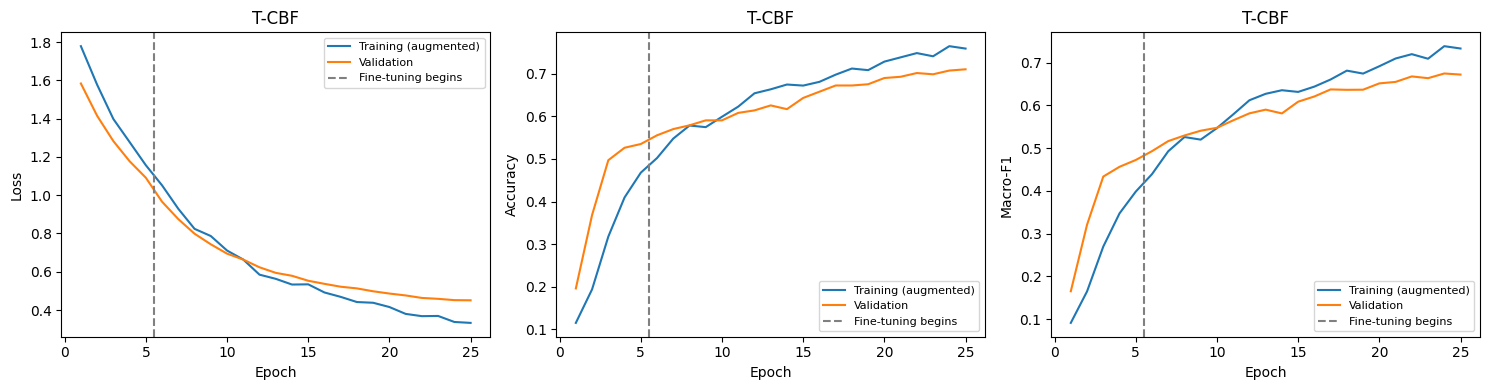

,epoch,phase,loss,macro_f1,top1_accuracy,top3_accuracy,val_loss,val_macro_f1,val_top1_accuracy,val_top3_accuracy,learning_rate_after_epoch
20,21,finetune,0.379627,0.709343,0.738587,0.924328,0.476102,0.654633,0.692982,0.915205,0.00001
21,22,finetune,0.367827,0.719507,0.748593,0.940588,0.463044,0.667492,0.701754,0.915205,0.00001
22,23,finetune,0.368882,0.708813,0.741088,0.938086,0.458337,0.663355,0.698830,0.912281,0.00001
23,24,finetune,0.337416,0.738201,0.764853,0.941213,0.451567,0.674329,0.707602,0.915205,0.00001
24,25,finetune,0.332666,0.732738,0.759225,0.945591,0.450661,0.671811,0.710526,0.921053,0.00001


Metrics: /content/drive/MyDrive/thesis/PetClassNet_12_Class_Prototype_25/metrics/T-CBF_seed42
Confusion matrices: /content/drive/MyDrive/thesis/PetClassNet_12_Class_Prototype_25/confusion_matrices/T-CBF_seed42
Validation selects the epoch; it is not an independent final-performance estimate.


In [12]:
if RUN_TRAINING:
    VALIDATION_REPORT = evaluate_prototype(CONTEXT, RECORD, 'validation')
    display(pd.DataFrame(VALIDATION_REPORT['per_class']))
    display(validation_comparison(CONTEXT))
    HISTORY = plot_prototype_history(CONTEXT, RECORD)
    display(HISTORY.tail())
    print('Metrics:', OUTPUT_ROOT / 'metrics' / RECORD['run_id'])
    print('Confusion matrices:', OUTPUT_ROOT / 'confusion_matrices' / RECORD['run_id'])
    print('Validation selects the epoch; it is not an independent final-performance estimate.')

In [13]:
if RUN_TRAINING:
    MODEL_ZIP = export_streamlit_model(CONTEXT, RECORD)
    from google.colab import files
    files.download(str(MODEL_ZIP))
    print('If the download is blocked, download the same ZIP from Drive:', MODEL_ZIP)

Streamlit model ZIP: /content/drive/MyDrive/thesis/PetClassNet_12_Class_Prototype_25/exports/PetClassNet_proposed_model.zip
Extract this ZIP into the folder containing streamlit_app.py; it creates/merges models/.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

If the download is blocked, download the same ZIP from Drive: /content/drive/MyDrive/thesis/PetClassNet_12_Class_Prototype_25/exports/PetClassNet_proposed_model.zip


## 8. Preview Top-3 and class-specific Grad-CAM
One validation image is used for this demonstration. Scores are not veterinary diagnoses. Heatmaps show class-score influence, not verified lesion localization or severity.

,rank,class,model_score
0,1,Cat - Dental Disease,0.621436
1,2,Dog - Dental Disease,0.300132
2,3,Dog - Eye Infection,0.028743


Cat - Dental Disease score: 0.6214361786842346


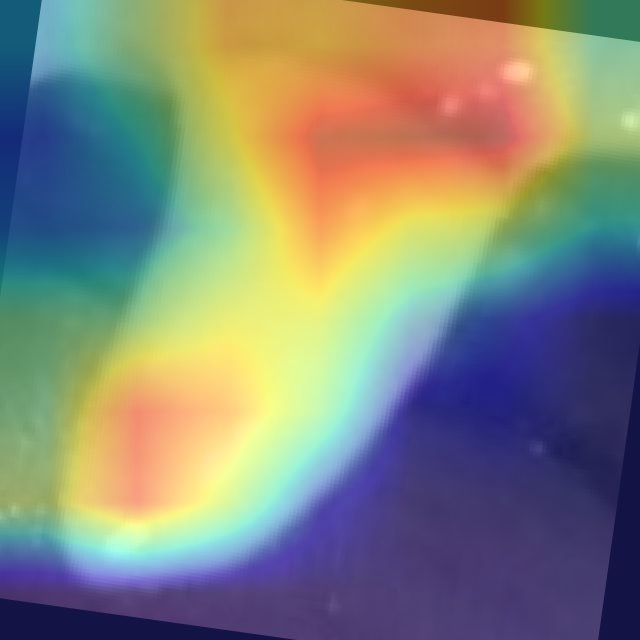

Dog - Dental Disease score: 0.30013158917427063


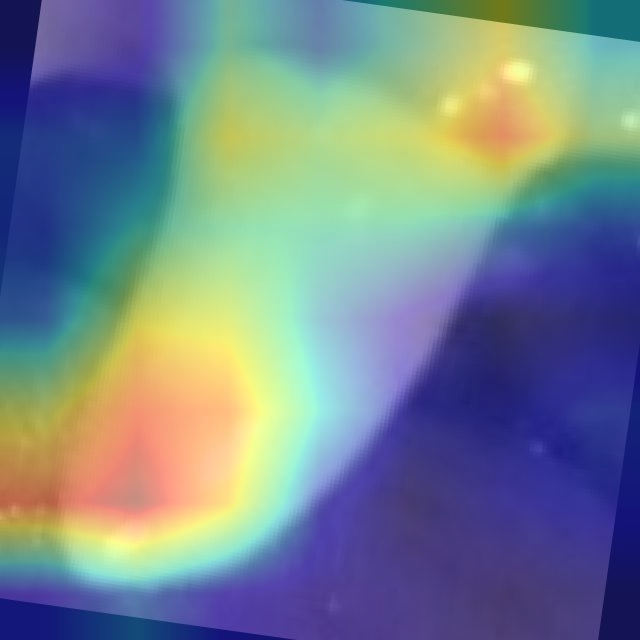

Dog - Eye Infection score: 0.02874288521707058


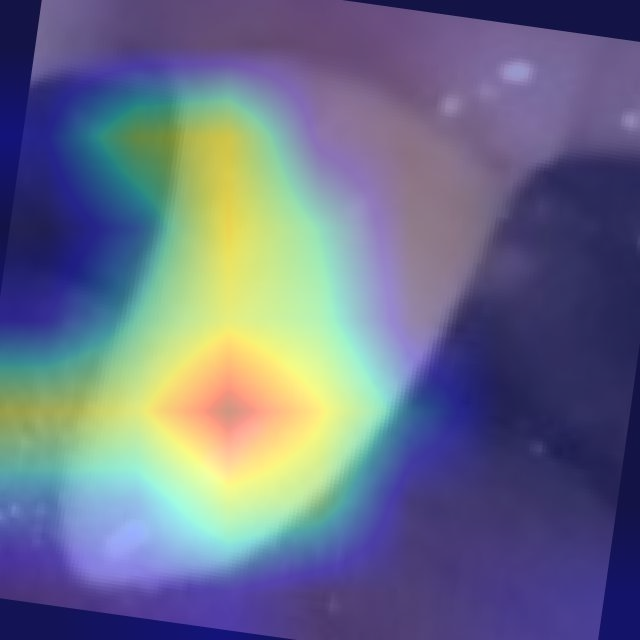

In [14]:
# Demonstrate on one VALIDATION image; this cell never reads the test partition.
if RUN_TRAINING:
    demo_path = DATA['manifest'].query("split == 'validation'").sort_values('relative_path').iloc[0].relative_path
    demo_model = tf.keras.models.load_model(OUTPUT_ROOT / RECORD['model_path'], compile=False)
    demo = gradcam_top3(demo_model, TRAINING_ROOT / demo_path, OUTPUT_ROOT, RECORD['run_id'], CLASS_NAMES)
    display(pd.DataFrame([{'rank': r['rank'], 'class': r['class_name'], 'model_score': r['model_confidence']}
                          for r in demo['top3']]))
    from IPython.display import Image as DisplayImage
    for result in demo['top3']:
        print(result['class_name'], 'score:', result['model_confidence'])
        display(DisplayImage(filename=result['overlay'], width=350))
    del demo_model
    tf.keras.backend.clear_session()

## Optional: one locked prototype test comparison
Leave `RUN_TEST_COMPARISON=False` for development and outline defense. If you decide to test, finish both 25-epoch runs first, freeze their settings and validation-selected checkpoints, then set the flag to True and run this cell. Both models are evaluated on the same held-out 15%. After viewing test scores, do not tune against them. A single-seed 25-epoch test cannot replace the paper’s final multi-configuration/multi-seed experiments; repeated prototype tuning may require a new, independent final holdout.

In [15]:
if RUN_TEST_COMPARISON:
    # Requires BOTH completed25-epoch runs. Locks the same validation-selected
    # models before test inference and reuses unchanged saved test reports.
    display(locked_test_comparison(CONTEXT))
    print('Descriptive single-seed prototype test only; do not use these scores to change the model or training settings.')
else:
    print('Test evaluation skipped. Keep this15% partition untouched while developing the prototype.')

Test evaluation skipped. Keep this15% partition untouched while developing the prototype.


## Run the Streamlit app on your laptop

1. Extract `PetClassNet_12_Class_Prototype_25.zip` into a folder on your laptop.
2. Extract the downloaded baseline/proposed model ZIPs into that folder. They place `.keras` and matching `.json` files in `models/`.
3. Follow `README.md`, or the run instructions at the top of `streamlit_app.py`:

```powershell
py -3.12 -m venv .venv
.\.venv\Scripts\python.exe -m pip install -r requirements.txt
.\.venv\Scripts\python.exe -m streamlit run streamlit_app.py
```

Open `http://localhost:8501`. Use **Compare both models** only with a matched pair of exports. Both remain twelve-class classifiers; no healthy/unknown category is learned.

Official implementation references: [EfficientNet-B0](https://www.tensorflow.org/api_docs/python/tf/keras/applications/EfficientNetB0), [Keras transfer learning](https://keras.io/guides/transfer_learning/), [Keras Grad-CAM](https://keras.io/examples/vision/grad_cam/), [Streamlit installation](https://docs.streamlit.io/get-started/installation).